# PROD-2. Контейнеризация и работа с облаками

# 1. Введение

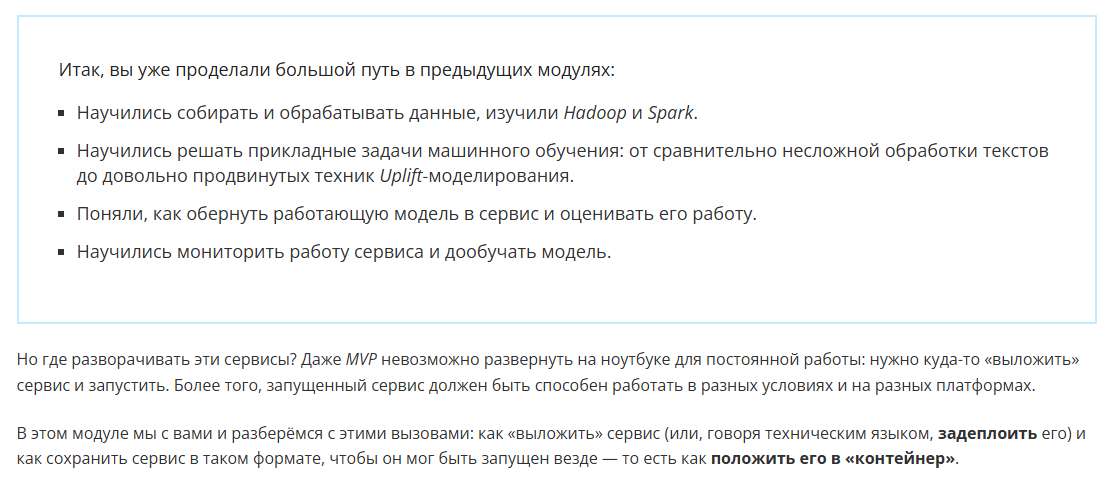

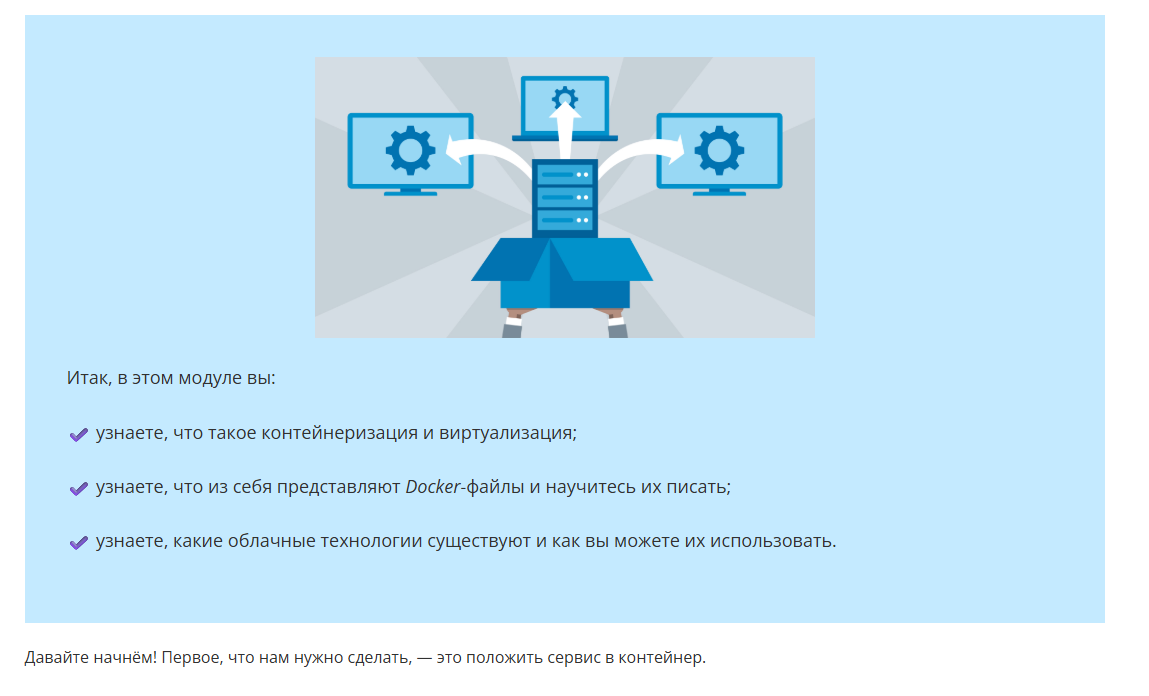

# 2. Контейнеризация

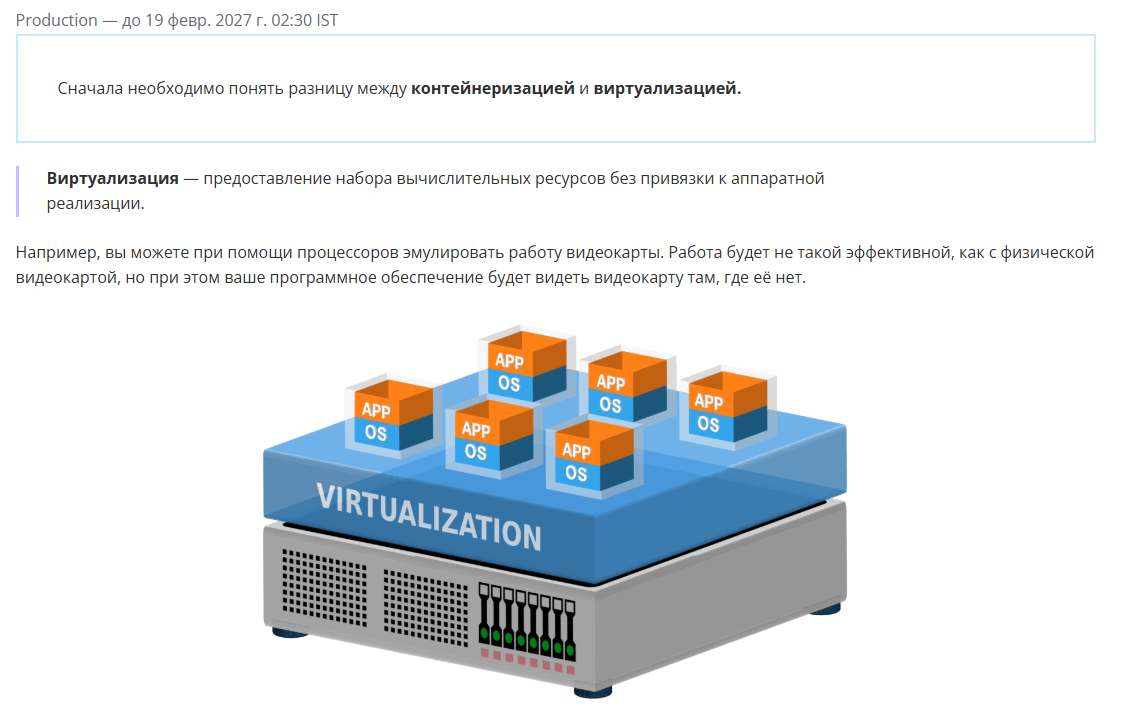

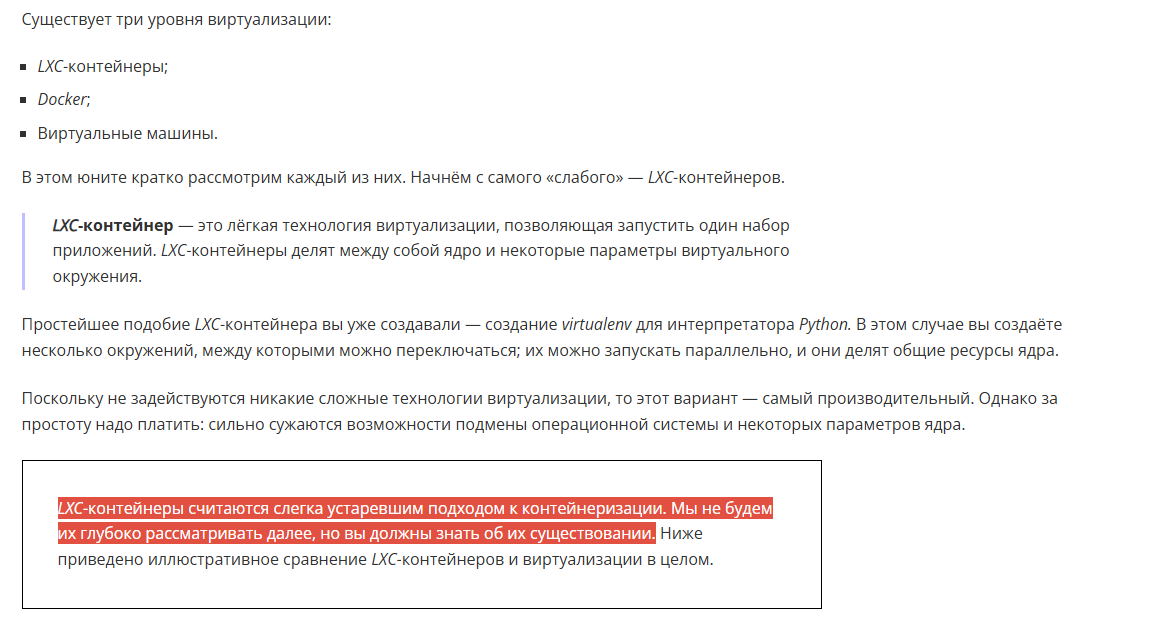

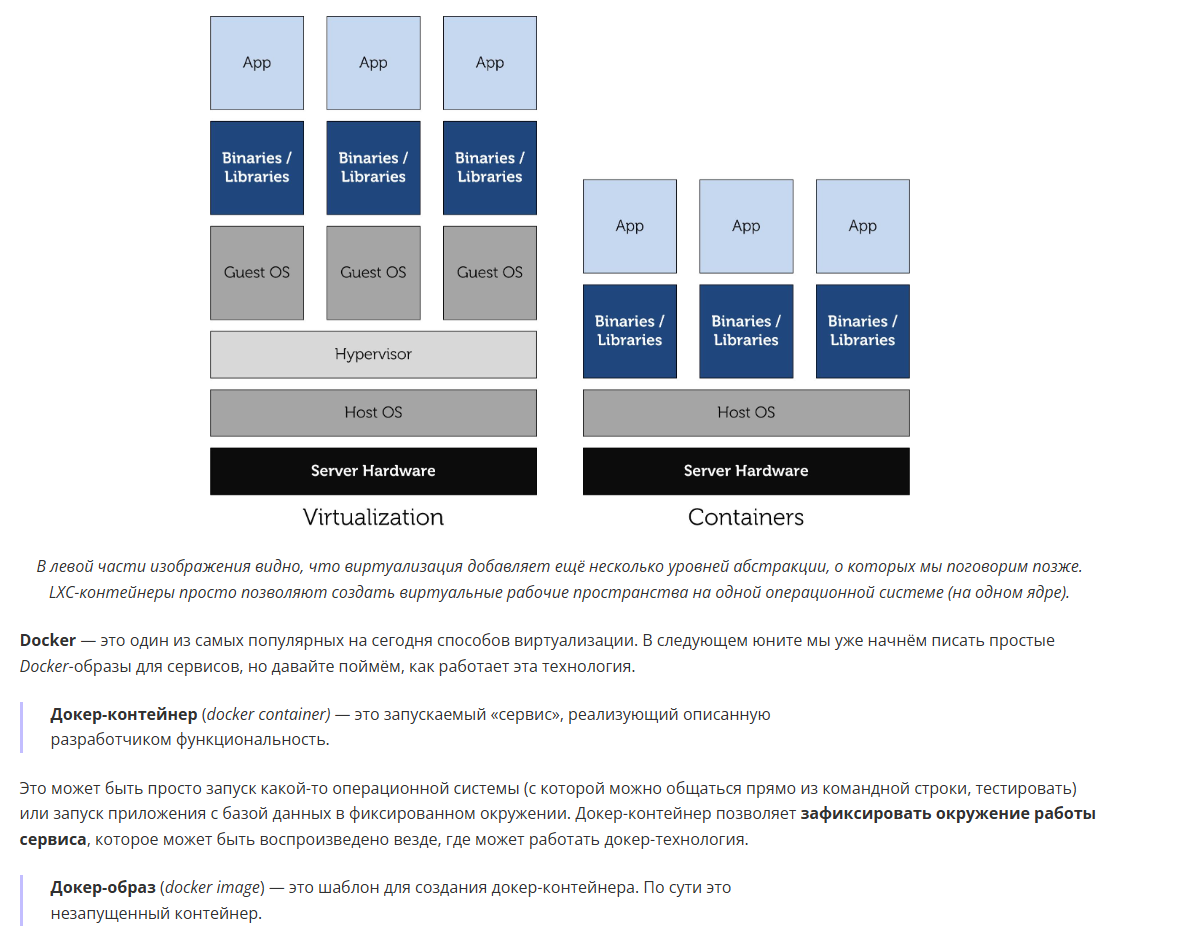

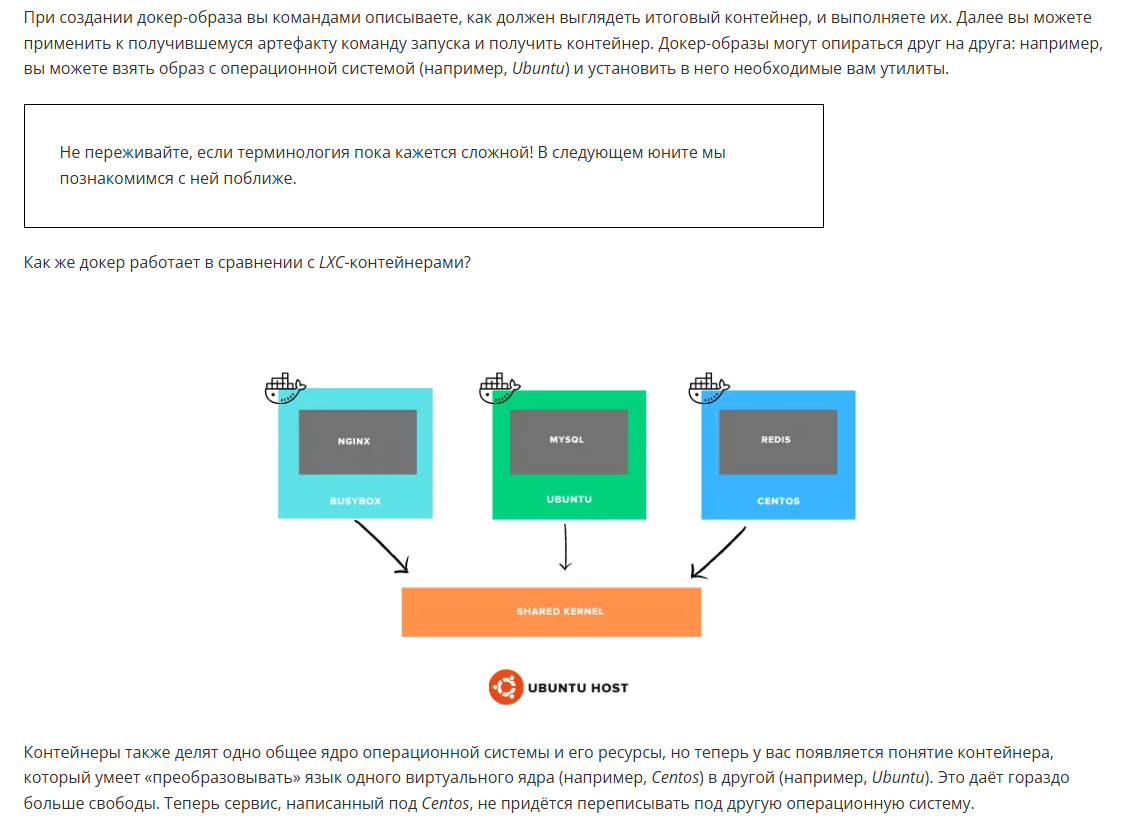

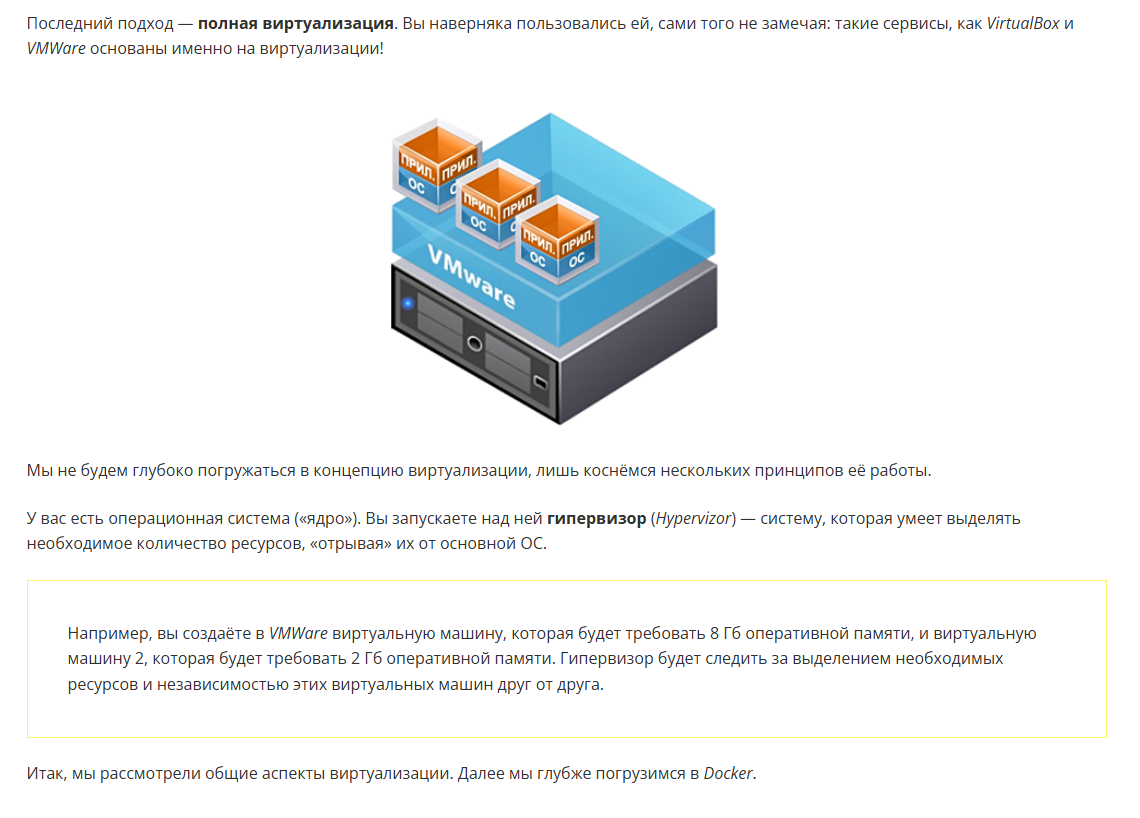

# 3. Docker

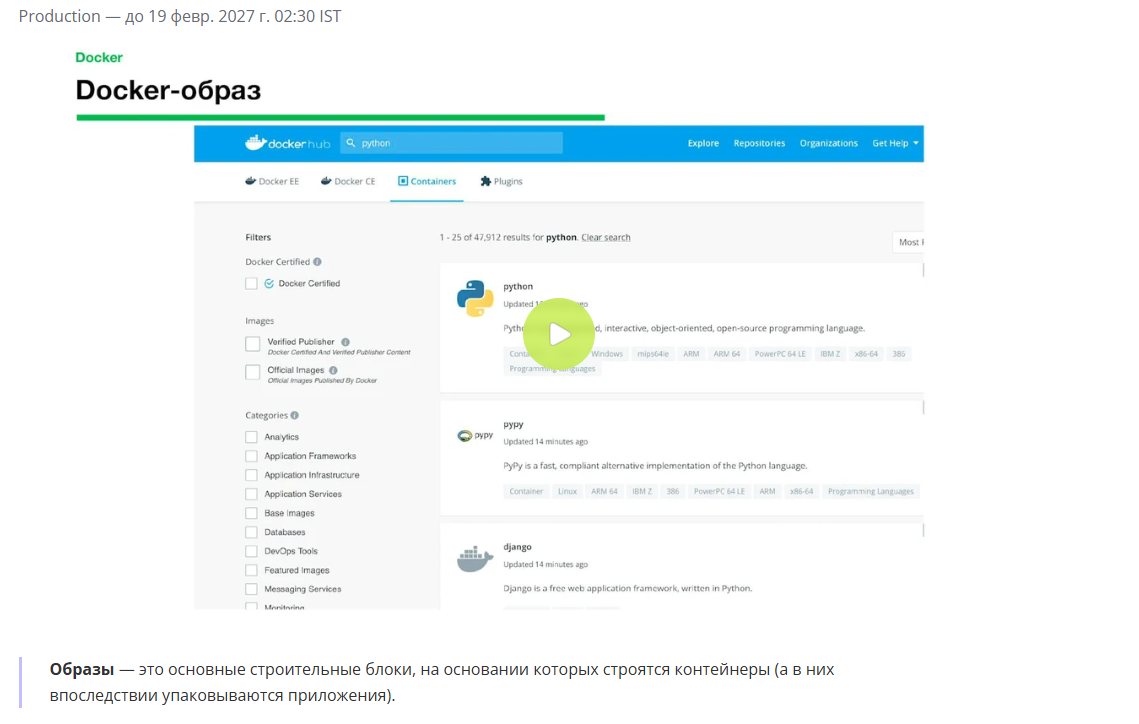

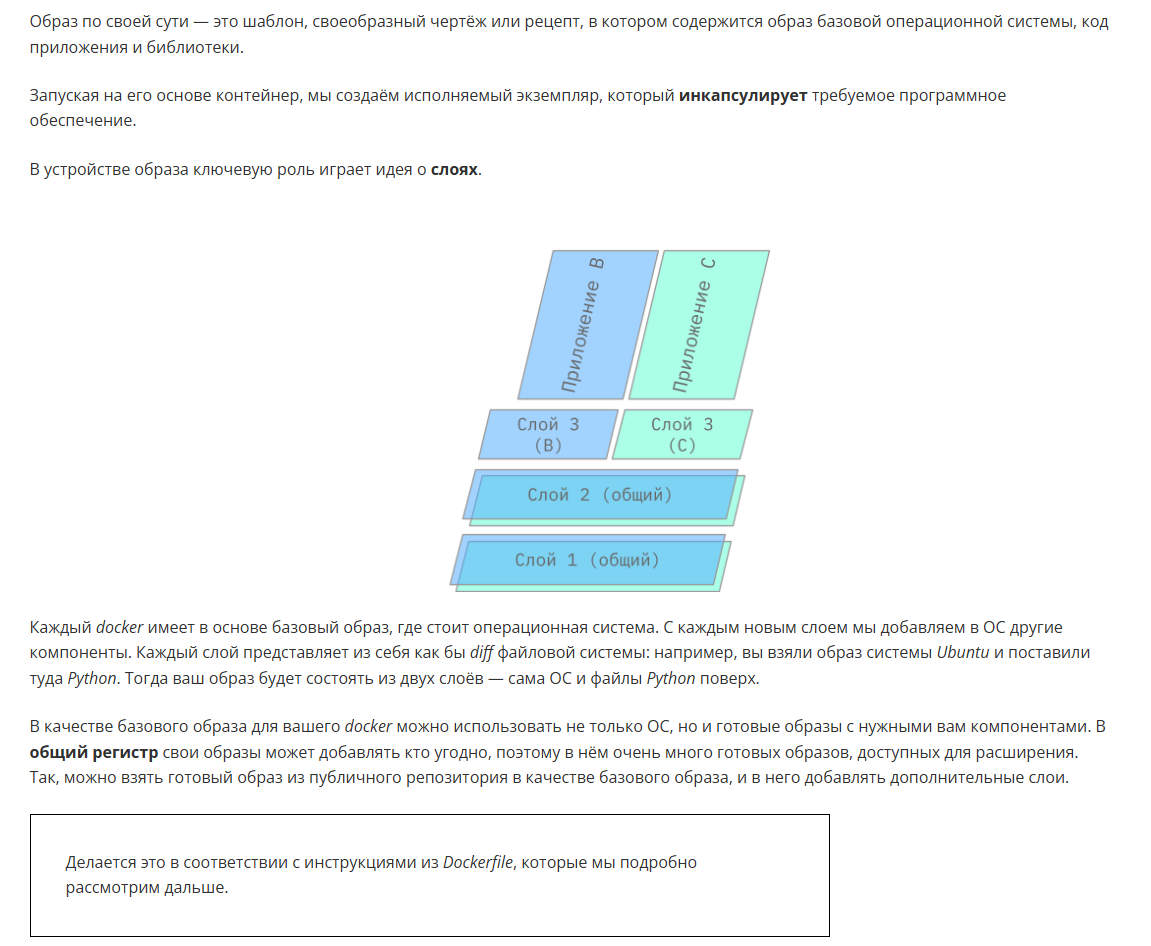

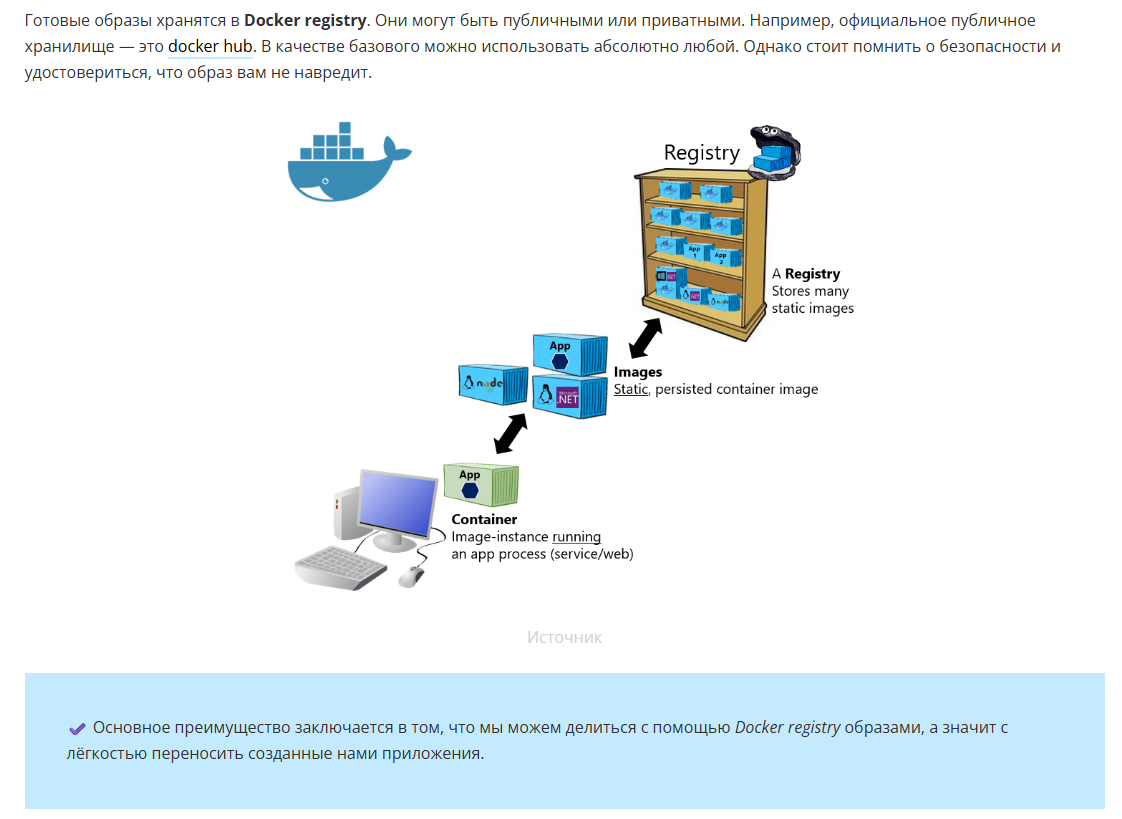

Для работы с Docker registry достаточно знать две команды:

1. Docker push — отправить собранный образ в Docker registry.
2. Docker pull — скачать готовый образ из Docker registry.

→ Существует множество официальных образов https://hub.docker.com/search?q=&type=image&image_filter=official. Например, можно найти образ, где в качестве ОС используется Ubuntu https://hub.docker.com/_/ubuntu, или, например, Linux с уже установленным Python https://hub.docker.com/_/python. Есть даже Docker в Docker https://hub.docker.com/_/docker! Очень удобно, не правда ли?

Docker-образ управляется Daemon, который отвечает за все действия, связанные с контейнерами и, конечно, самим клиентом для взаимодействия с ним.

→ Прежде чем мы перейдём к созданию собственного Docker-контейнера, давайте установим сам Docker!

### ДЛЯ ПОЛЬЗОВАТЕЛЕЙ LINUX и MACOS

Если вы работаете из IDE VSCode, то просто поставьте расширение Docker. Если нет, то вы можете скачать десктопную версию Docker с официального сайта разработчика. https://www.docker.com/products/docker-desktop

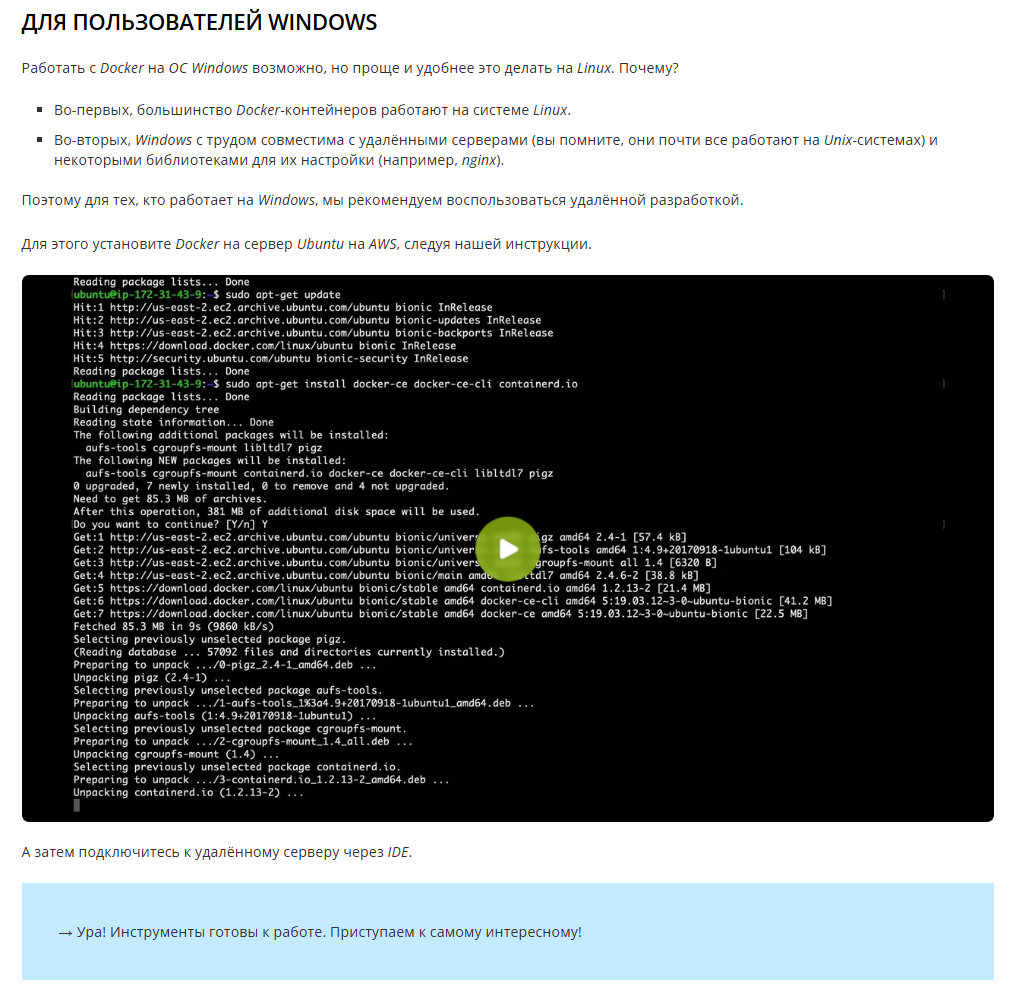

# 4. Dockerfile. Теория

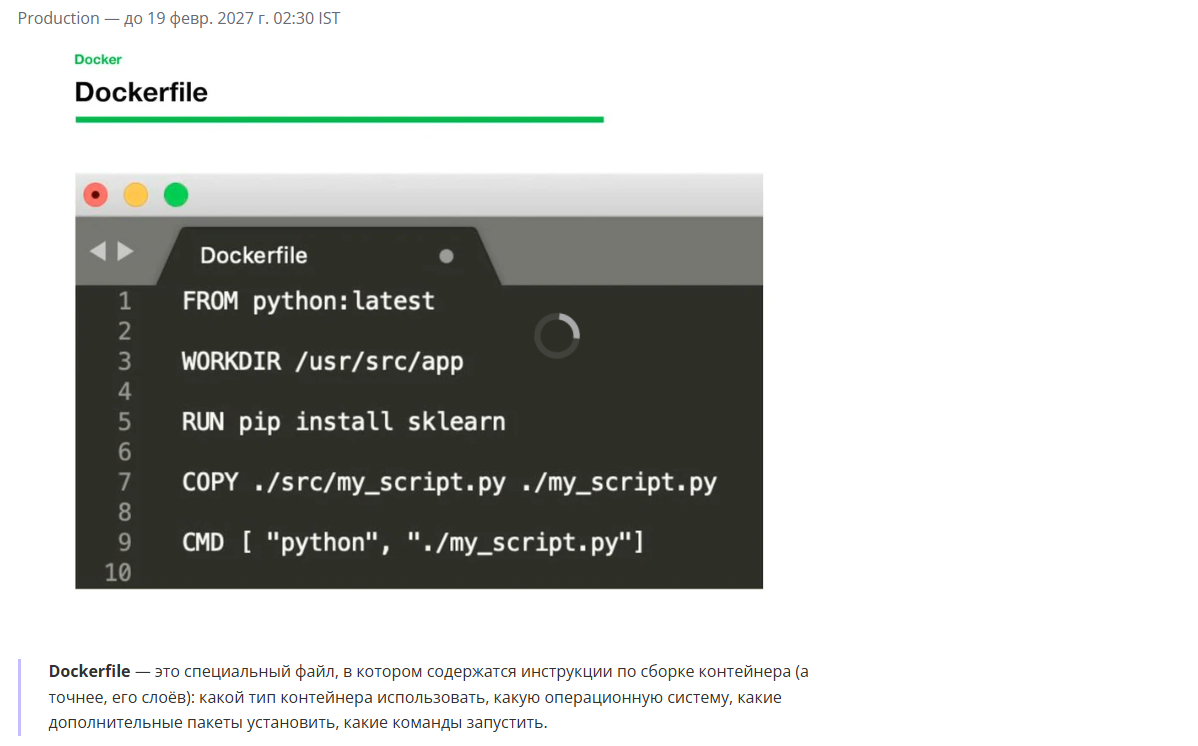

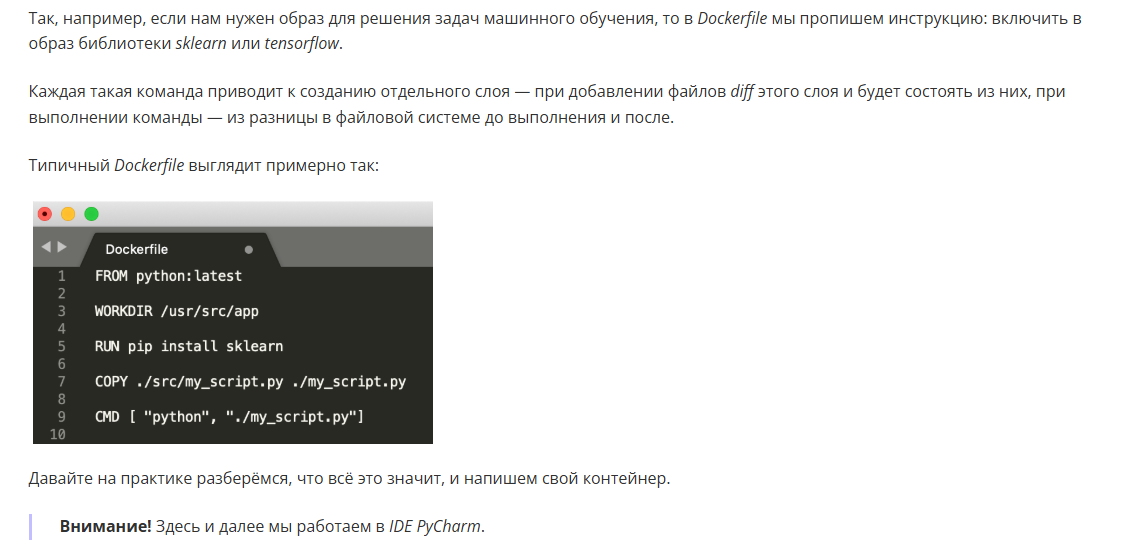

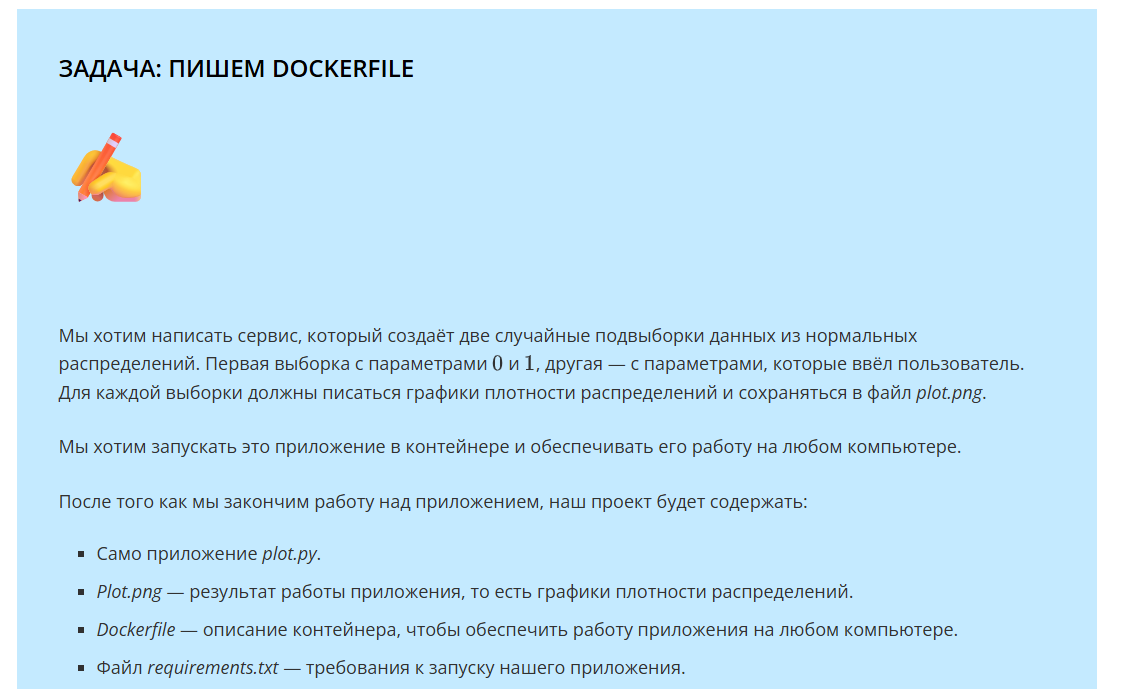

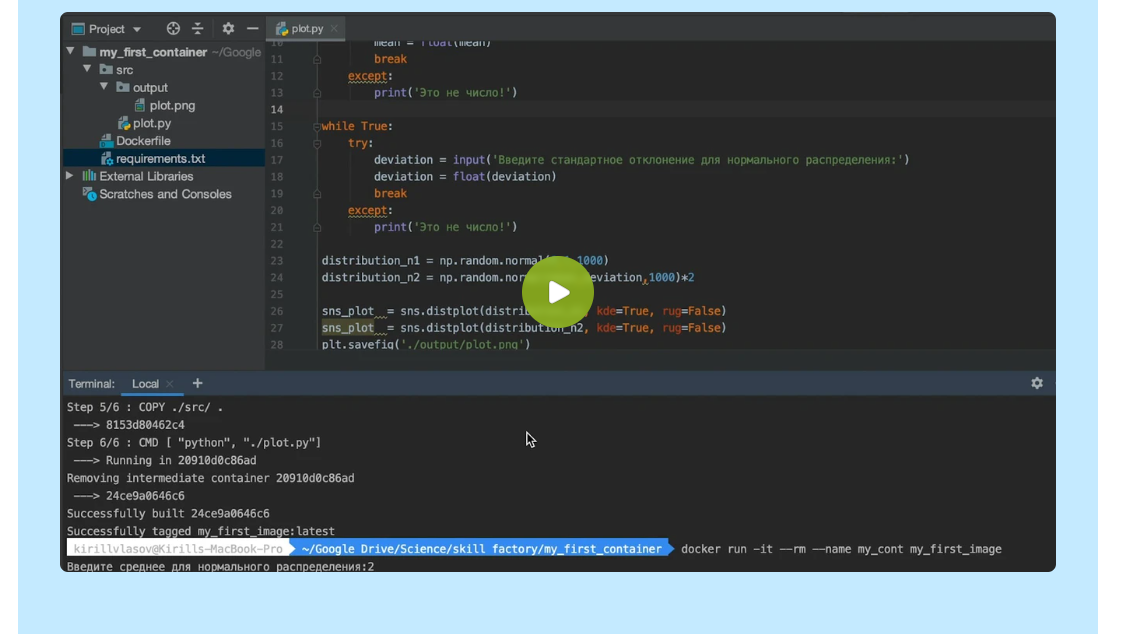

## Шаг 1

Начнём с того, что напишем само приложение и сохраним его в файл plot.py: 

In [ ]:
#!/usr/bin/env python
# coding: utf-8
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

while True:
    try:
        mean = input('Введите среднее для нормального распределения:') 
        mean = float(mean)
        break
    except:
        print('Это не число!')

while True:
    try:
        deviation = input('Введите стандартное отклонение для нормального распределения:') 
        deviation = float(deviation)
        break
    except:
        print('Это не число!')

distribution_n1 = np.random.normal(0,1,1000)            
distribution_n2 = np.random.normal(mean,deviation,1000)*2       

sns_plot  = sns.distplot(distribution_n1, kde=True, rug=False)
sns_plot  = sns.distplot(distribution_n2, kde=True, rug=False)
plt.savefig('./output/plot.png')

print('Файл успешно сохранен')

## Шаг 2

Следующим шагом будет создание собственного образа на основе базового.

Для этого создайте файл Dockerfile (без расширения) в корне папки, в которой лежит ваше приложение.

Откройте Dockerfile в любом текстовом редакторе (или в привычной IDE). Для скрипта plot.py и папки output лучше создать ещё одну директорию — тогда итоговая структура будет выглядеть следующим образом: 

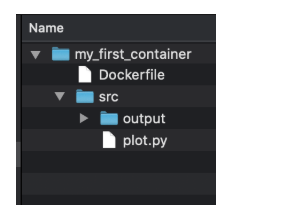

Первое, что нужно указать в нашем новом Dockerfile, — какой образ мы берём за основу. 

Давайте загрузим в качестве основы образ Linux с уже установленным Python. https://hub.docker.com/_/python

Итак, первая строчка нашего Dockerfile: 

In [ ]:
FROM python:3.8

:3.8 в названии указывает на версию образа. https://hub.docker.com/_/python

→ В описании образа мы можем ознакомиться с информацией о том, какие бывают сборки и версии. 

Например, существует обычная сборка python:<version> или python:<version>-alpine, собранная на базе Alpine Linux. Эта сборка весит намного меньше, чем большинство базовых образов дистрибутива (~ 5 МБ).

Кроме того, существует python:<version>-slim, который не содержит стандартных пакетов, а только минимальные пакеты, необходимые для запуска Python. Мы выбираем самую последнюю версию.

Расписываем наш файл дальше. Укажем путь к рабочей папке нашего приложения внутри docker-контейнера (вместо /usr/src/app вы можете прописать любой путь, по которому вы хотите поместить файлы внутри контейнера):

In [ ]:
WORKDIR /usr/src/app

Далее скопируем в рабочую директорию файлы из корня нашего приложения:

In [ ]:
COPY ./src/ .

Напишем команду для запуска скрипта:

In [ ]:
CMD [ "python", "./plot.py" ]

Теперь откроем командную строку, перейдём в папку с нашим приложением и запустим команду: 

In [ ]:
$ docker build -t my_first_image .

build указывает клиенту, что мы хотим создать образ. 

-t указывает на название образа.

. в конце указывает, что Dockerfile нужно искать именно в корне. 

Запускаем команду и видим, что образ успешно создан!

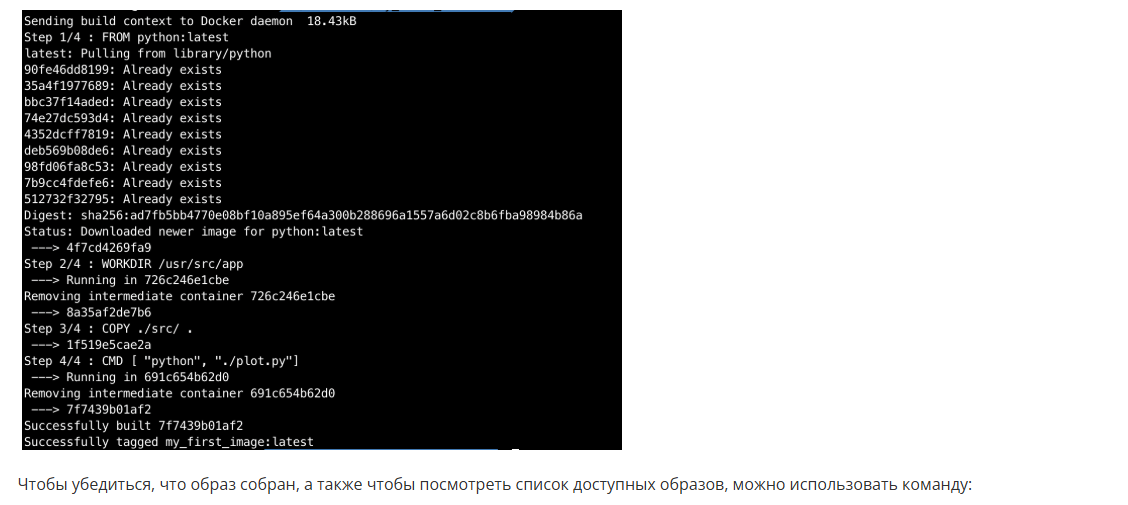

In [ ]:
docker images

Если вы до этого не работали с Docker, скорее всего, сейчас вы получите два образа: python и my_first_image.

Удалять лишние образы можно с помощью команды:

In [ ]:
docker rmi <image_id>


## Шаг 3. Запуск docker-контейнера

Попробуем запустить контейнер на основе нашего образа:

In [ ]:
$ docker run -it --rm --name my_first_image my_first_image

Расшифровываем:

1. -it объединяет команды;
2. -i оставляет строку для ввода;
3. -t выделяет терминал;
4. --name назначает docker-контейнеру имя;
5. --rm автоматически удаляет контейнер после завершения его работы (в том числе при завершении с ошибкой).

После запуска мы увидим ошибку Python:

In [ ]:
Traceback (most recent call last):
  File "./plot.py", line 4, in <module>
    import seaborn as sns
ModuleNotFoundError: No module named 'seaborn'

Эта ошибка говорит нам, что какие-то библиотеки не установлены. Добавим их в Dockerfile!

Для этого создадим файл requirements.txt рядом с Dockerfile, в котором укажем необходимые библиотеки и их версии:

- numpy == 1.19.2;
- matplotlib == 3.3.2;
- seaborn == 0.11.0. 

Напишите в Dockerfile после директивы WORKDIR строки: 

In [ ]:
COPY requirements.txt ./
RUN pip install --no-cache-dir -r requirements.txt

→ RUN позволяет запускать любые команды по аналогии с терминалом. 

→ --no-cache-dir позволяет не использовать кэш, а скачать пакеты заново. 

→ -r указывает на файлы с зависимостями.

## Шаг 4

Заново соберите образ: 

In [ ]:
$ docker build -t my_first_image .

Запустите контейнер:

In [ ]:
$ docker run -it --rm --name my_first_image my_first_image

Теперь всё работает корректно. Однако файл plot.png не появился в папке со скриптом. Давайте его искать! 

## Куда пропал plot.png?

Мы потеряли его после выполнения (технически он удалился вместе с контейнером после того, как запустился и выполнился скрипт plot.py). Docker не сохраняет файлы внутри контейнера, так как внутри контейнера своя отдельная файловая система.

Что же делать? Ответ очень прост: нам нужно связать контейнер с локальной файловой системой на нашем компьютере!

Для этого мы укажем ключ --volume, или -v в команде docker run.

Ключ -v требует указания путей, которые записываются в формате <путь на локальной машине>:<путь в контейнере>:

In [ ]:
$ docker run -it --rm -v $PWD/src/output/:/usr/src/app/output  --name my_first_image my_first_image

Если вы всё сделали правильно, то после выполнения команды в папке output появится нужный нам график.

## Теперь всё?

Иногда нам может потребоваться задать переменные среды, которые используются для определения констант. Для того чтобы задать их, в Dockerfile существует инструкция ENV, после чего значение будет доступно в контейнере во время его выполнения. 

→ Синтаксис можно найти в официальной документации. https://docs.docker.com/reference/dockerfile#env

Для этого в Dockerfile нужно добавить: 

In [ ]:
ENV <key> <value>
ENV <key>=<value> ...

Или, к примеру, при запуске контейнера: 

In [ ]:
docker run --env <key>=<value>

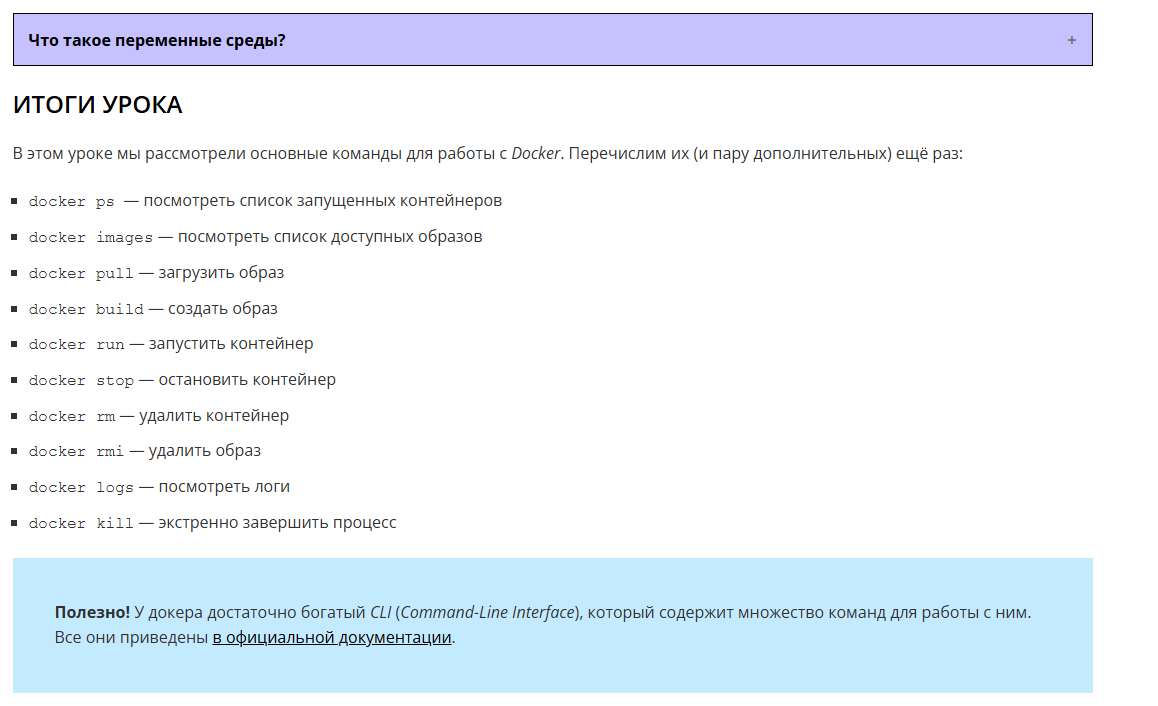

https://docs.docker.com/engine/containers/run/

# 5. Dockerfile. Практика

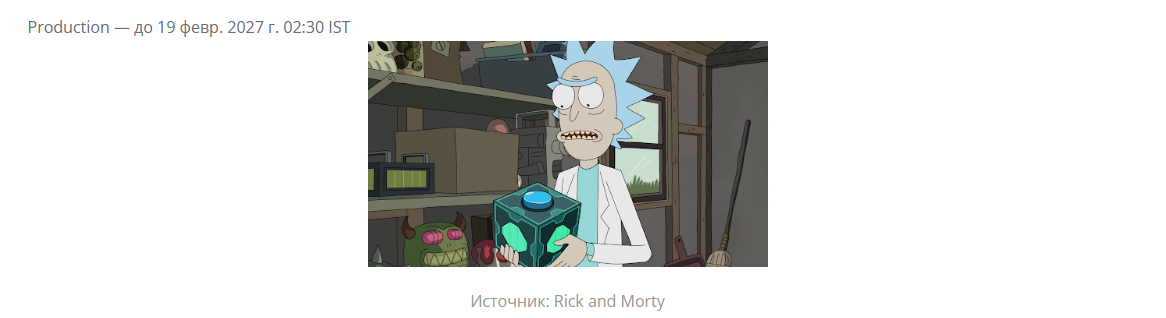

А теперь вам предстоит выполнить упражнение с Docker самостоятельно.

Шаг 1. Мы подготовили для вас специальный базовый образ, в котором зашит секретный код, как мы это любим. Чтобы его узнать, вам нужно создать свой образ на основе образа mike0sv/sf_docker_base и добавить в него текстовый файл с фразой I know how to use docker.

Шаг 2. Заведите переменную среды под названием DATA_PATH, которая должна содержать в себе добавленный вами путь к файлу внутри контейнера (относительный или абсолютный).

Шаг 3. Запустите контейнер. Если вы всё сделали правильно, он выведет секретный код. Введите его в поле ниже.

In [ ]:
docker build -t my_first_image_practice .

In [ ]:
docker run -it --rm --name my_cont my_first_image_practice

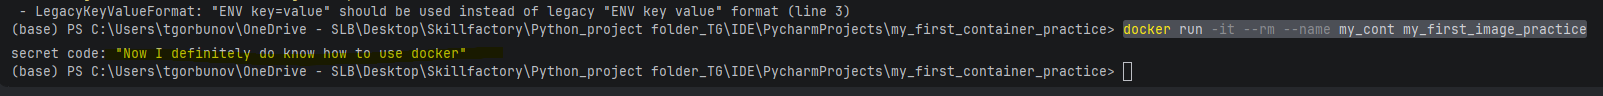

# 6. Ограничения сервисов

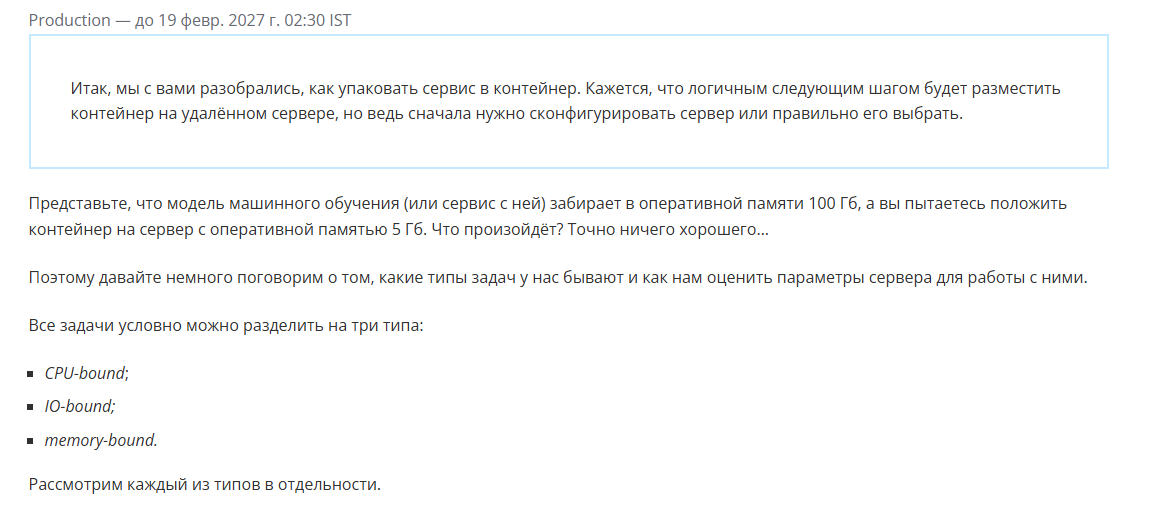

## cpu-bound

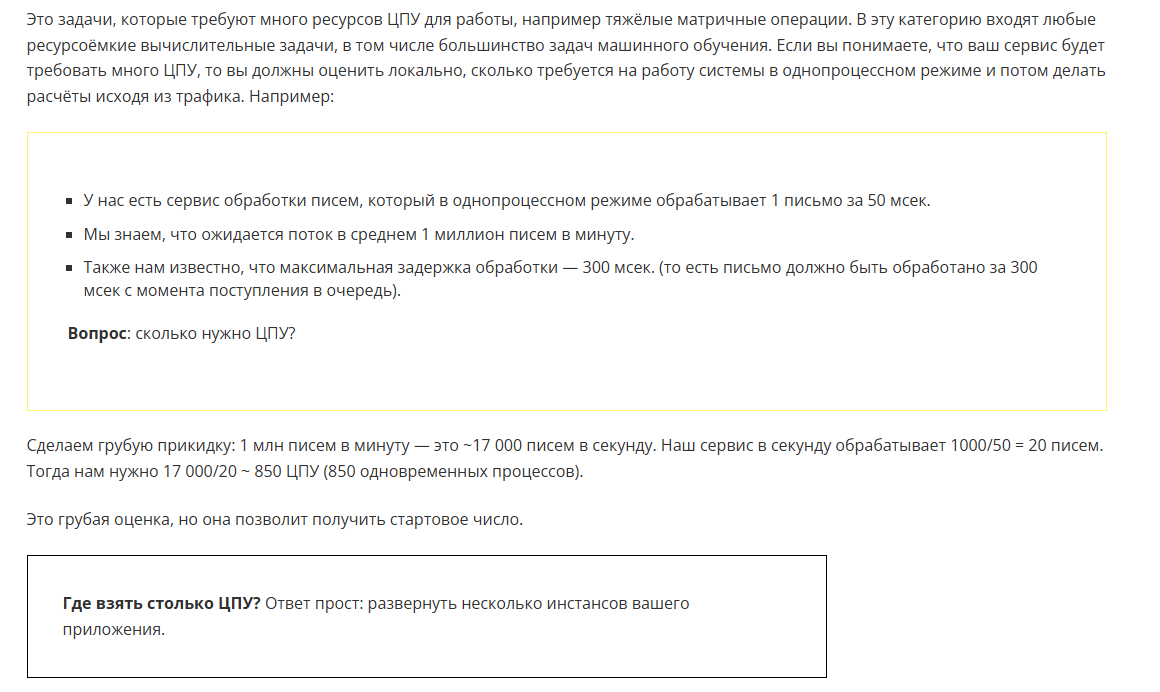

## io-bound

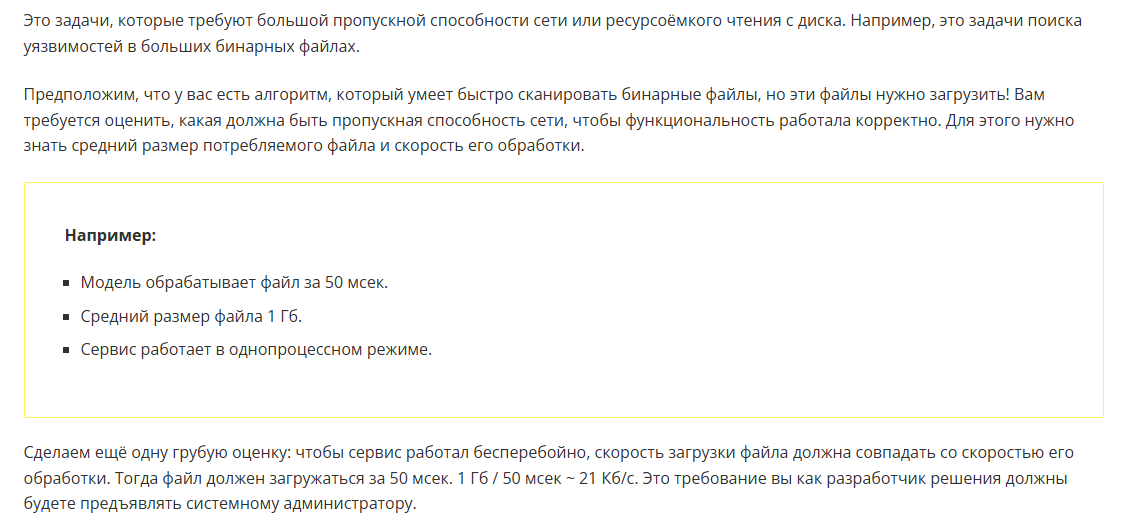

## Memory-bound

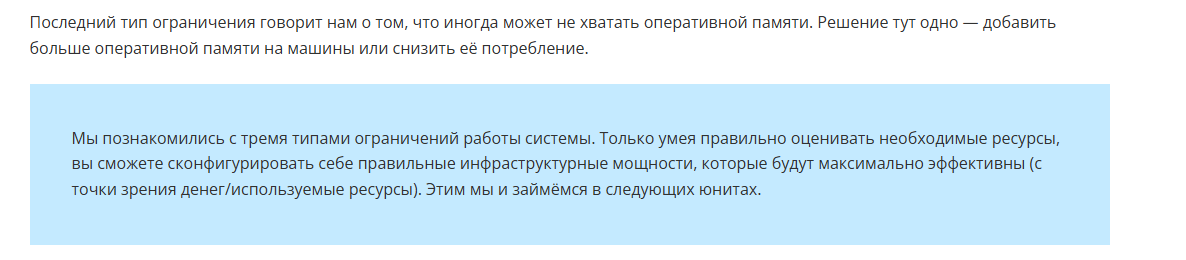

# 7. Облачные вычисления. Масштабируемость

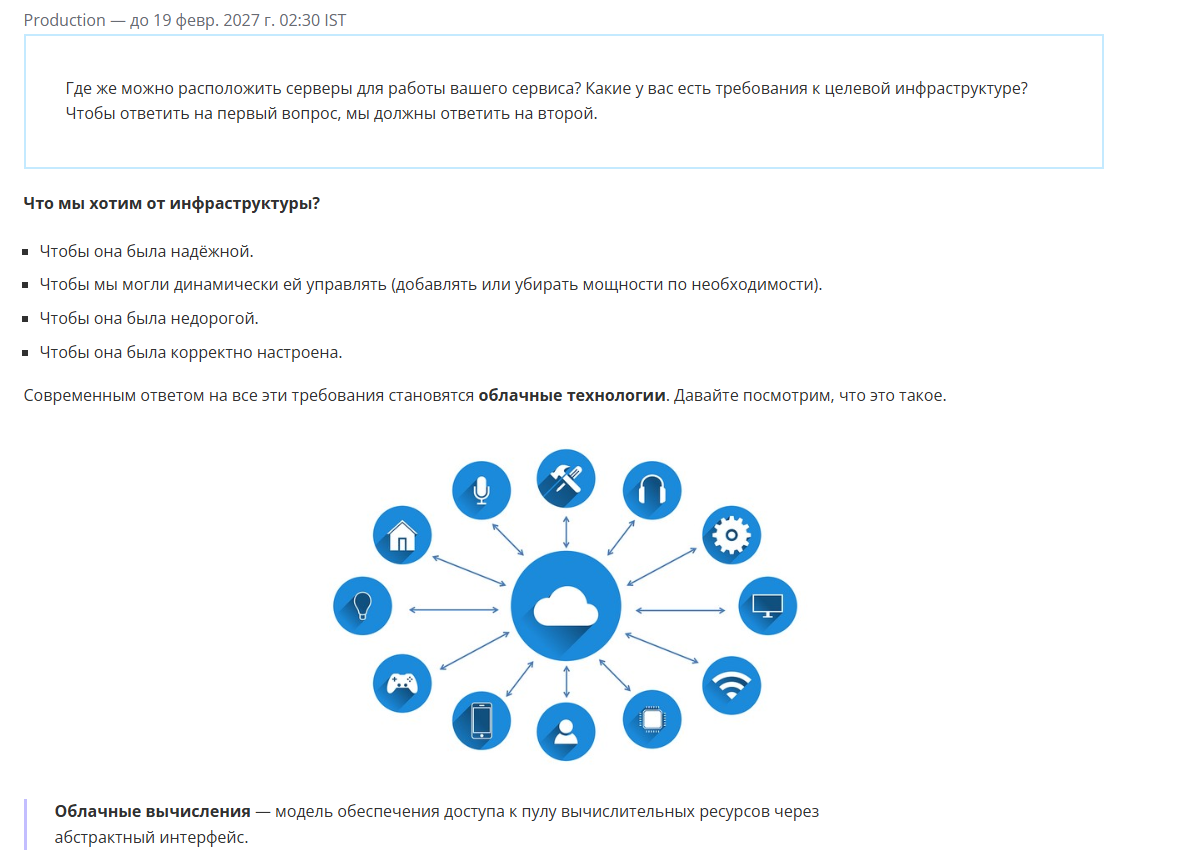

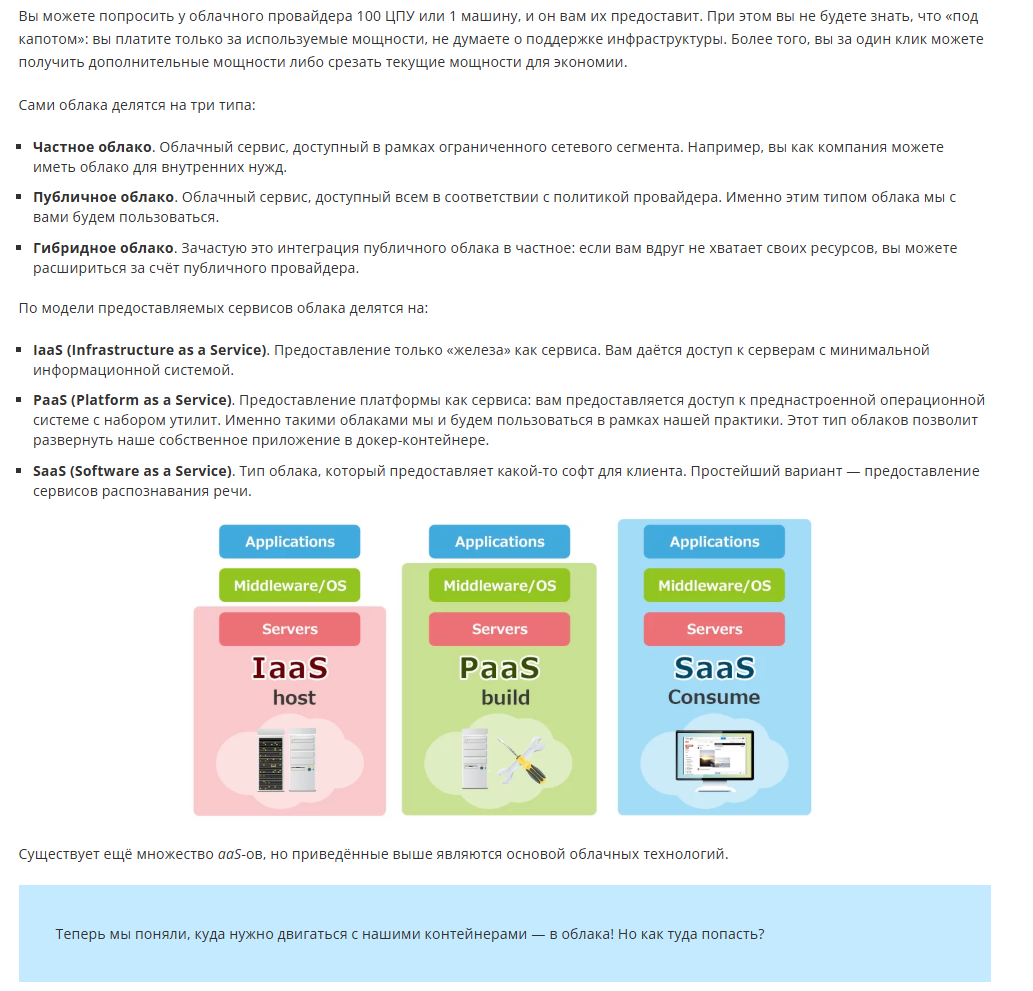

# 8. Облачные вычисления. Примеры

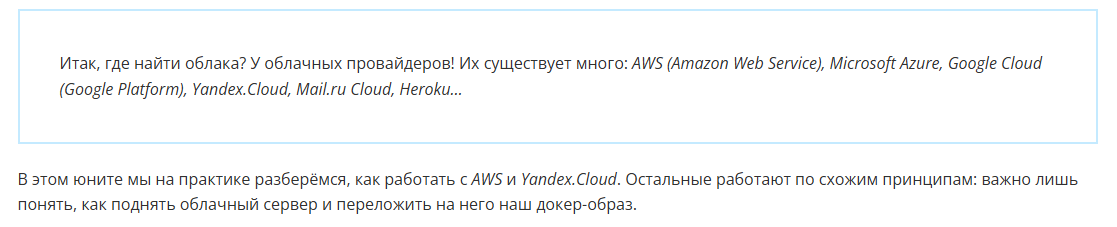

## Yandex.Cloud

https://yandex.cloud/ru?utm_referrer=https%3A%2F%2Fcloud.yandex.ru%2F&utm_referrer=https%3A%2F%2Fyandex.cloud%2Fshowcaptchafast%3Fd%3DDD5A82C1B5113C5C6A0A6436F867EC9FA1B5701F5A62CCD964D5413626220B8CFC25E476F9B02BA51892ECC67EE7C0D10B534B34ED%26retpath%3DaHR0cHM6Ly95YW5kZXguY2xvdWQvP3V0bV9yZWZlcnJlcj1odHRwcyUzQSUyRiUyRmNsb3VkLnlhbmRleC5ydSUyRg%252C%252C_ff317d7767454a0faf31478fc8b78374%26s%3Dc9bb59e0a27b7877308a12f56aaa597f

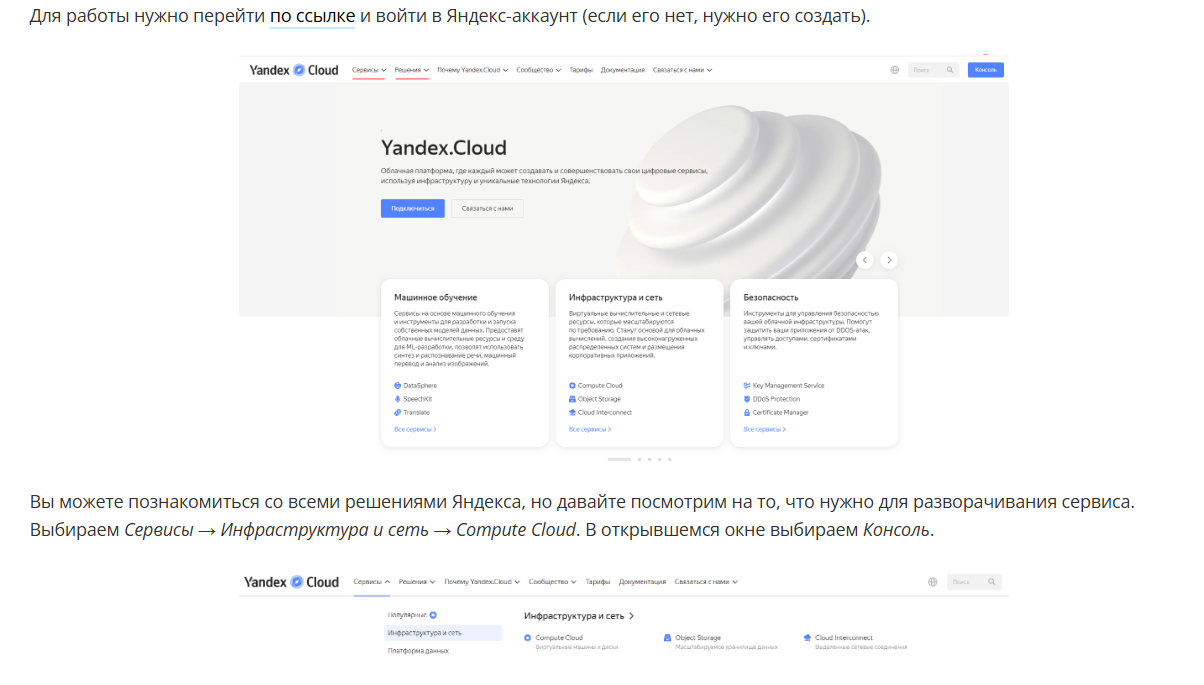

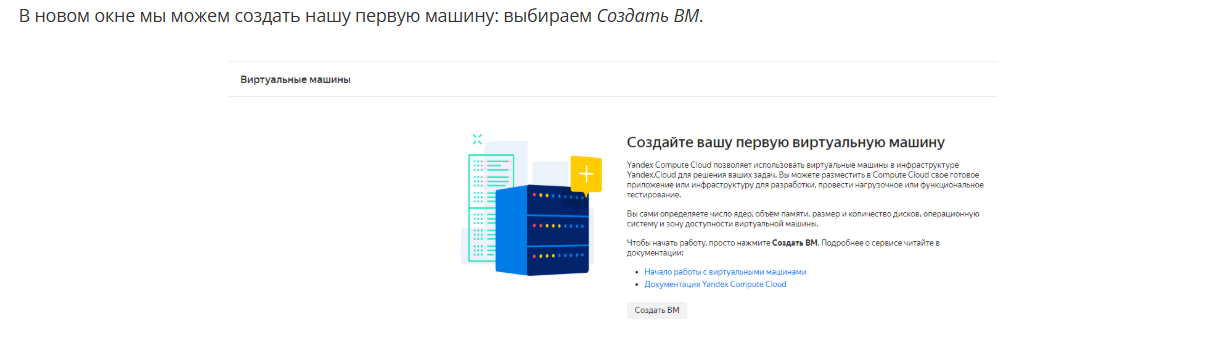

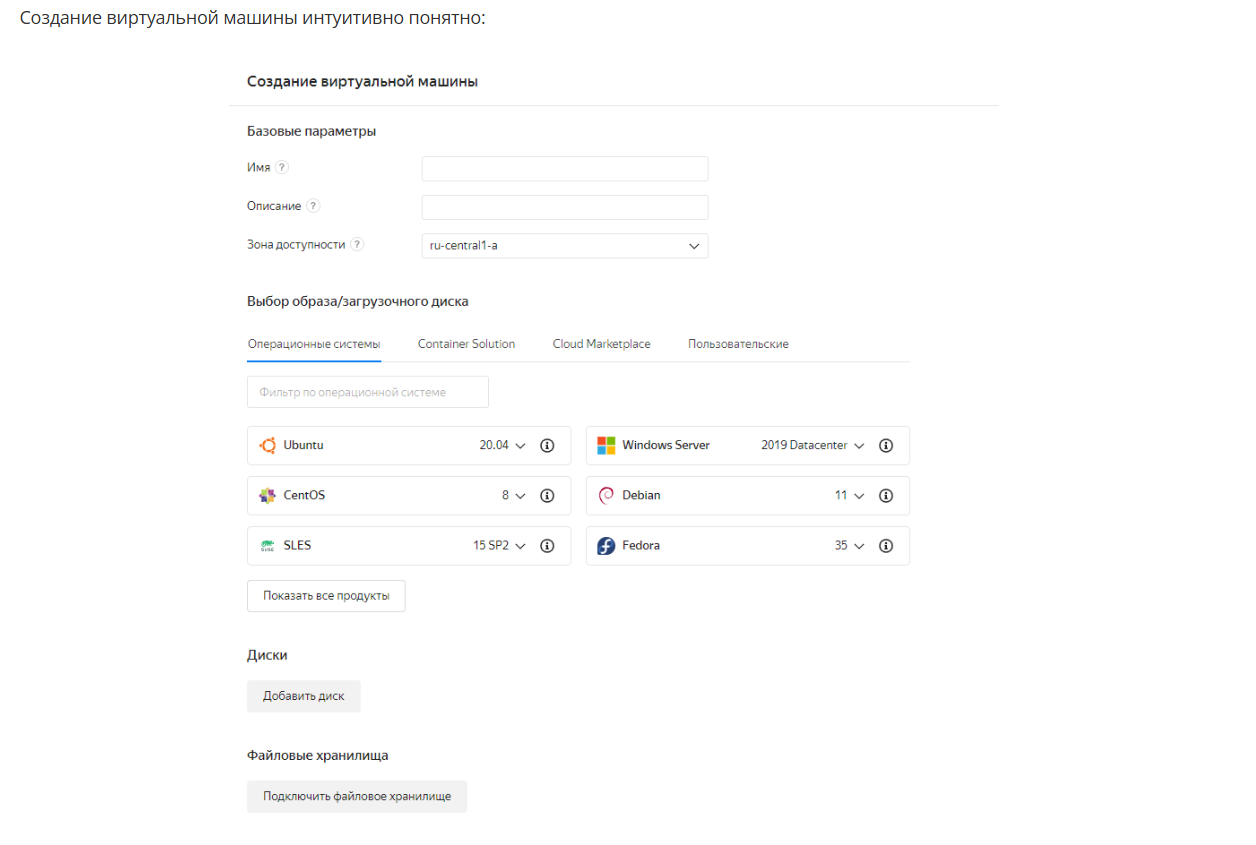

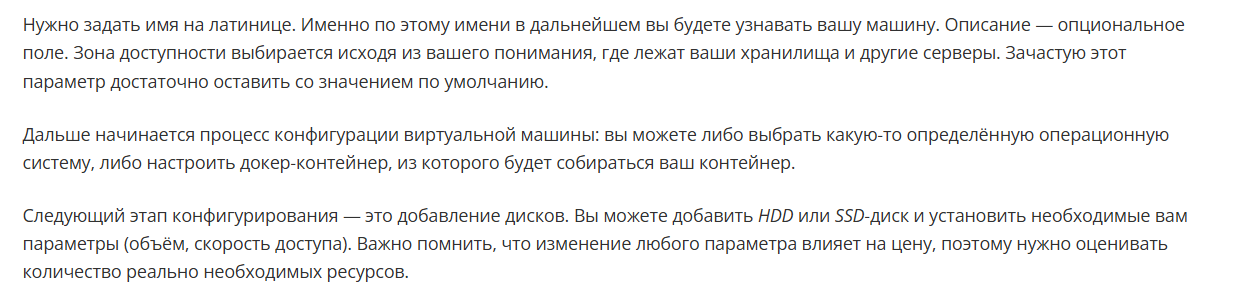

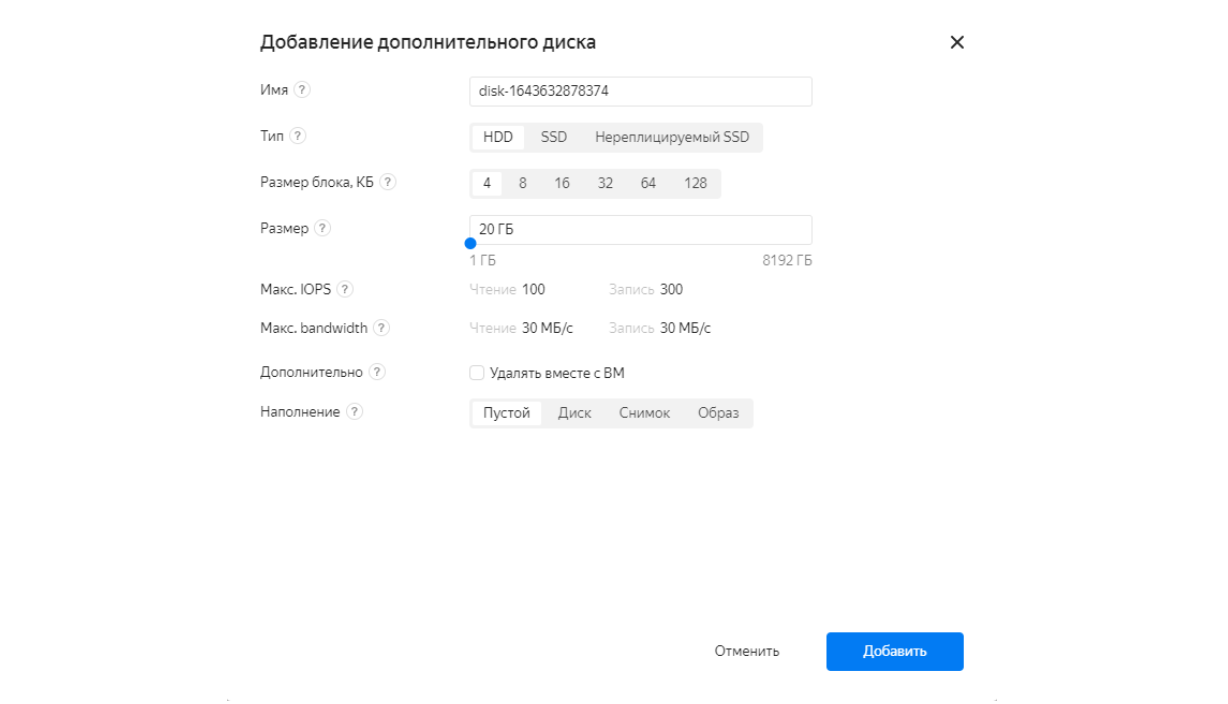

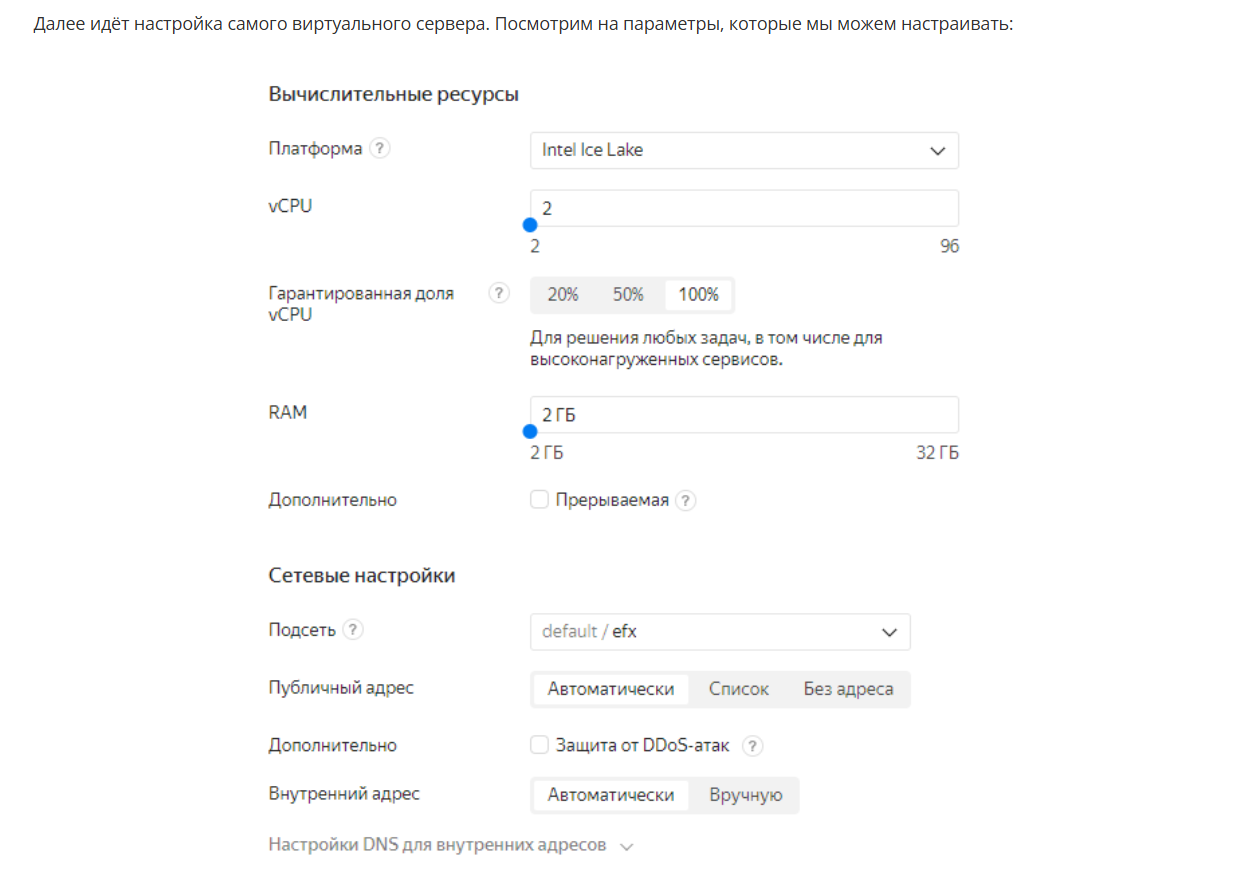

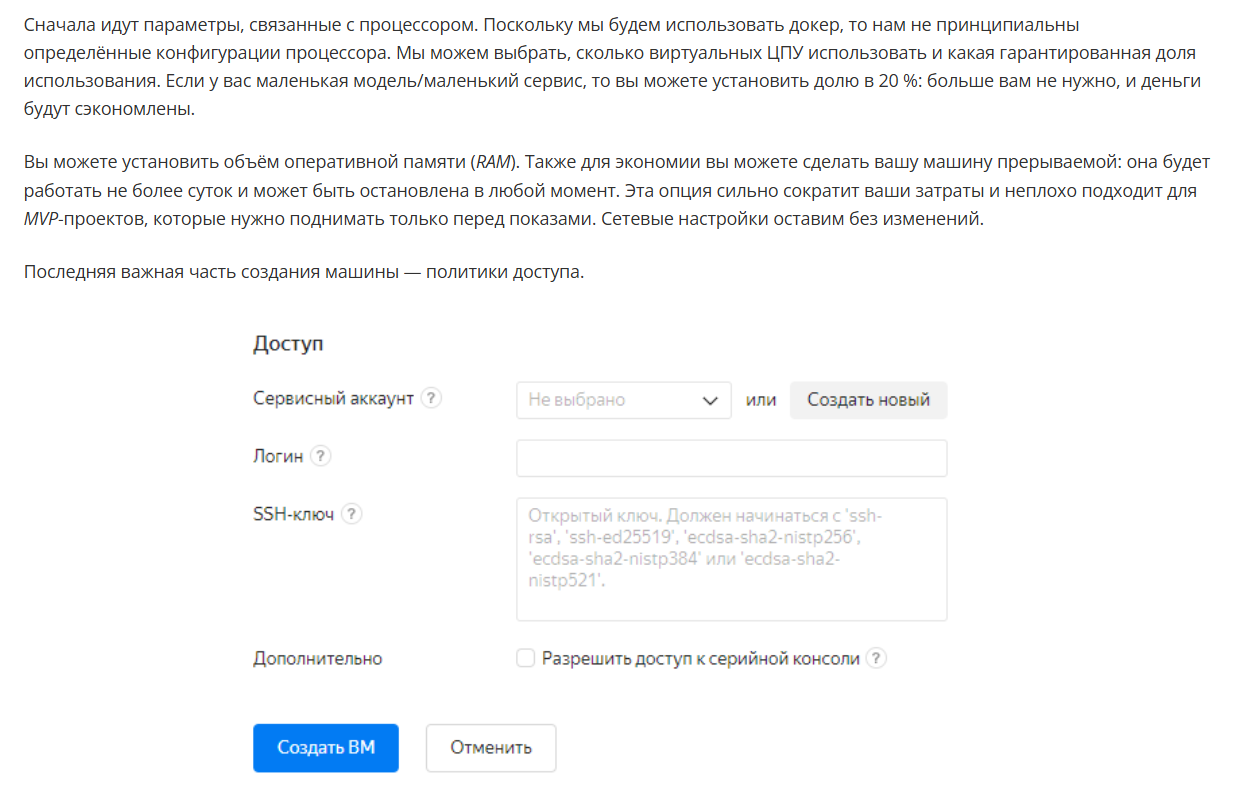

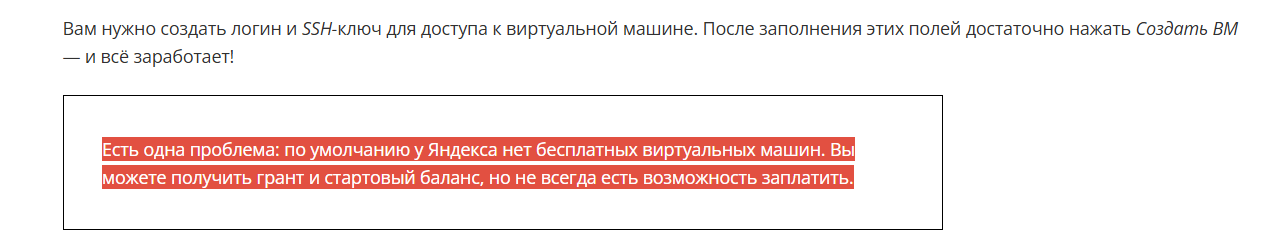

## Amazon Web Services

Давайте посмотрим на западного конкурента, у которого есть возможность создания бесплатных виртуальных машин — Amazon Web Services (AWS). https://eu-west-1.signin.aws.amazon.com/oauth?client_id=arn%3Aaws%3Asignin%3A%3A%3Aconsole%2Fec2-tb&code_challenge=Pktsg1_Kgi4kj8rtMWMD4cb7vwj7SEyaThzvmDRDgjk&code_challenge_method=SHA-256&response_type=code&redirect_uri=https%3A%2F%2Feu-west-1.console.aws.amazon.com%2Fec2%2Fv2%2Fhome%3Fca-oauth-flow-id%3D4f33%26hashArgs%3D%2523Home%26isauthcode%3Dtrue%26oauthStart%3D1787967551953%26region%3Deu-west-1%26state%3DhashArgsFromTB_eu-west-1_00a38cc7d54ea43d



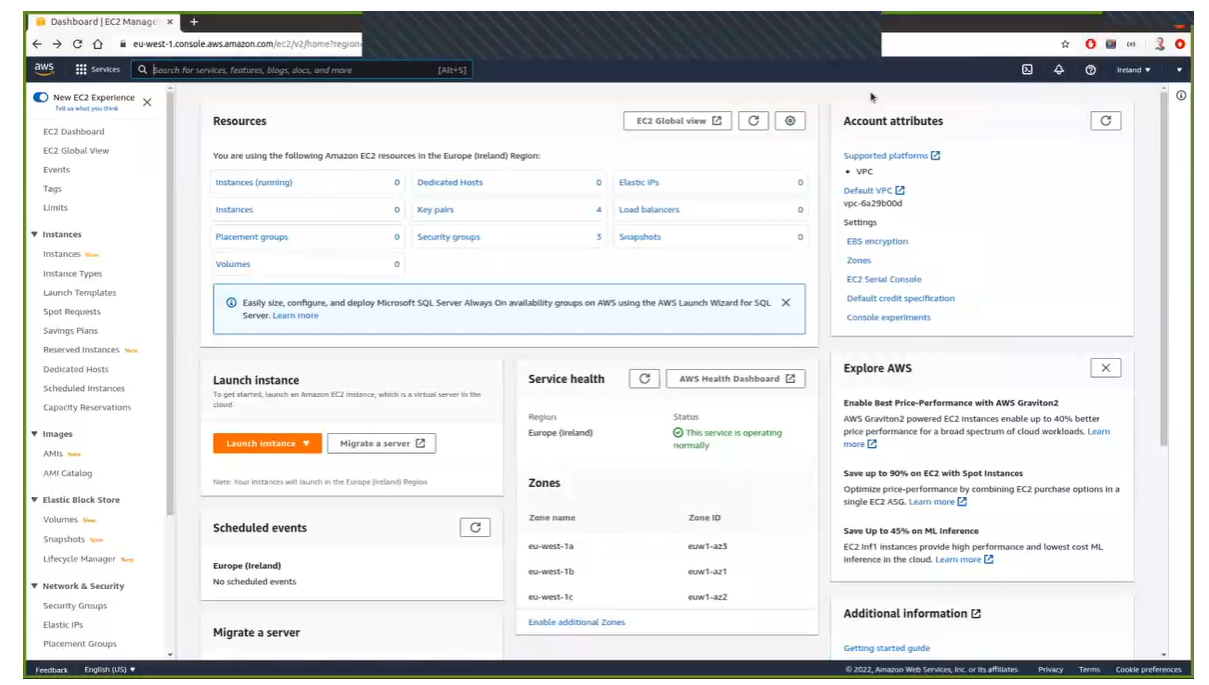

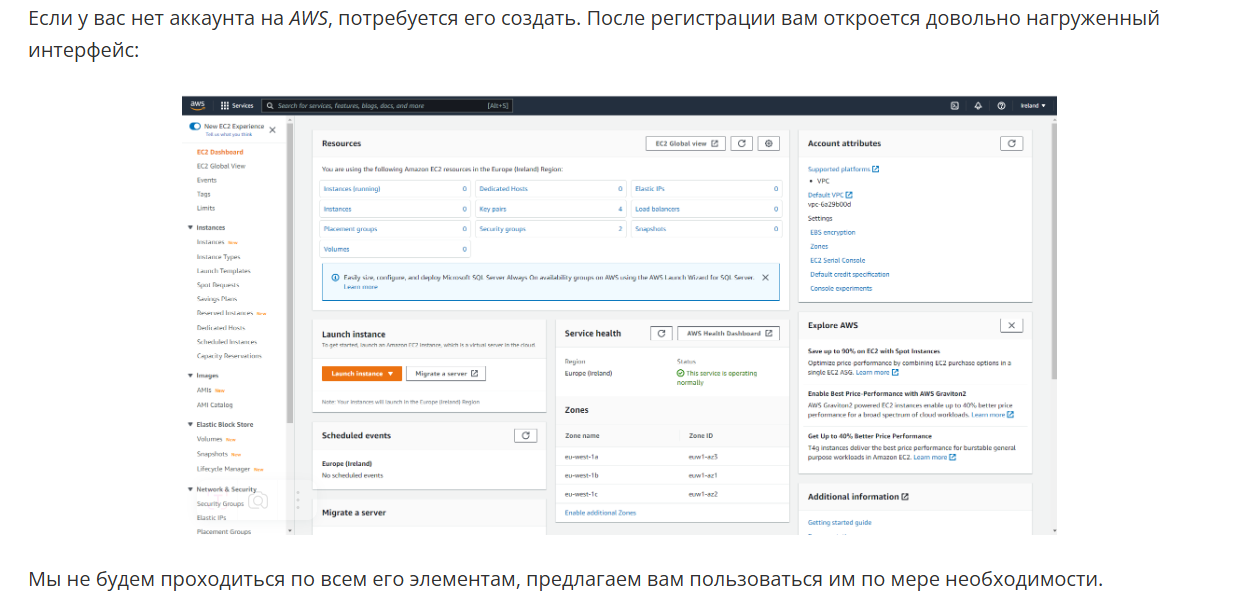

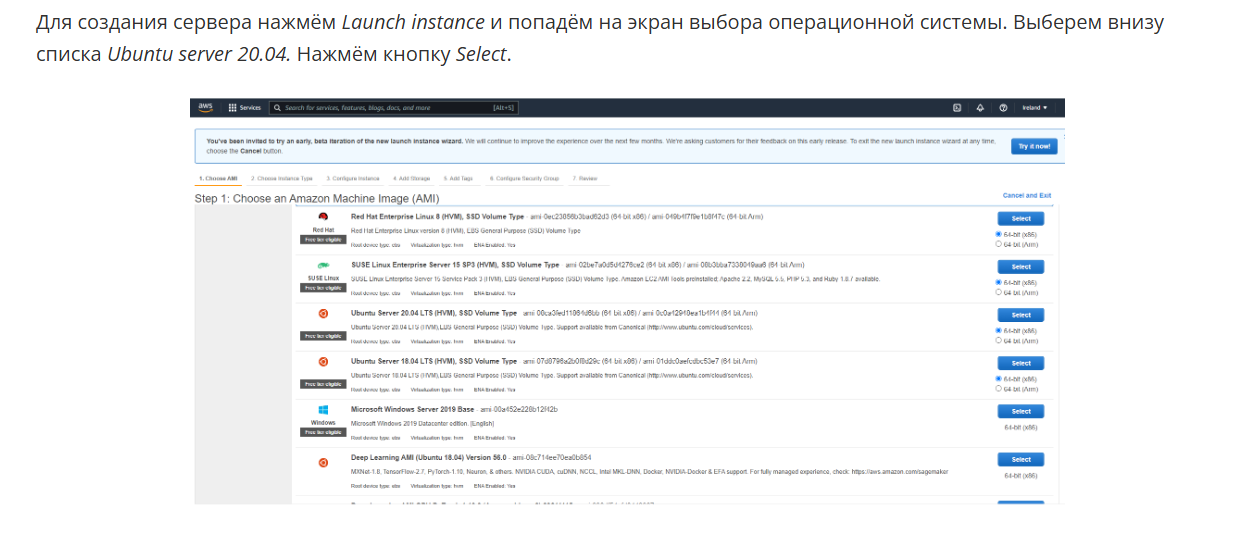

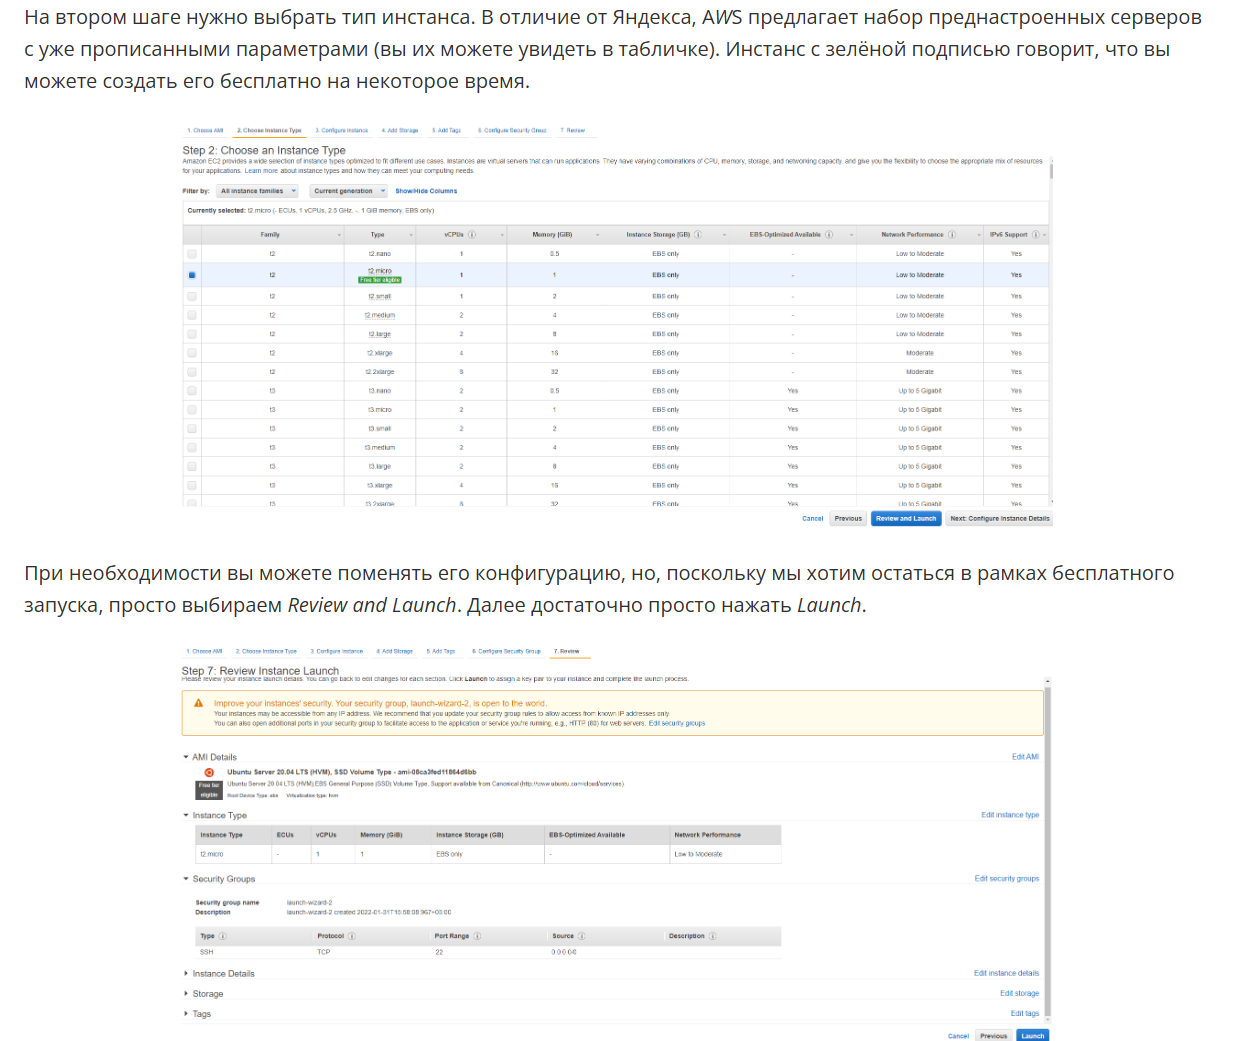

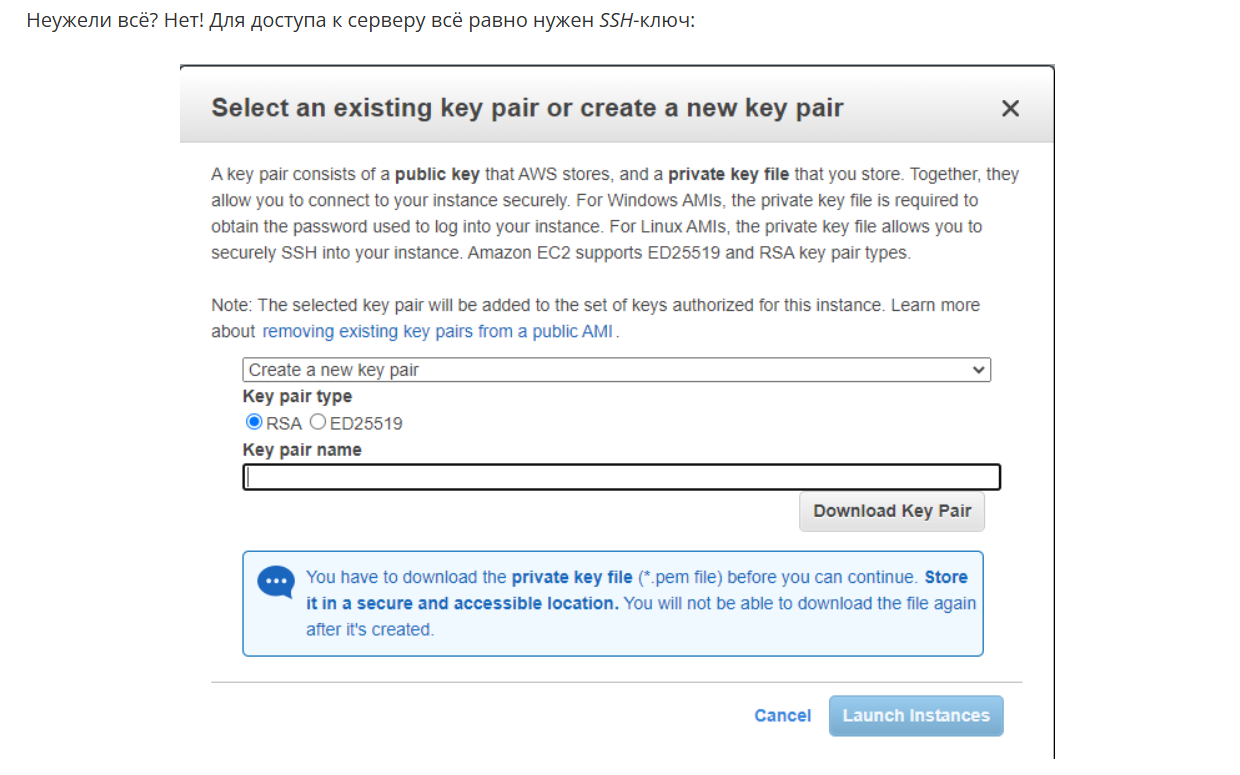

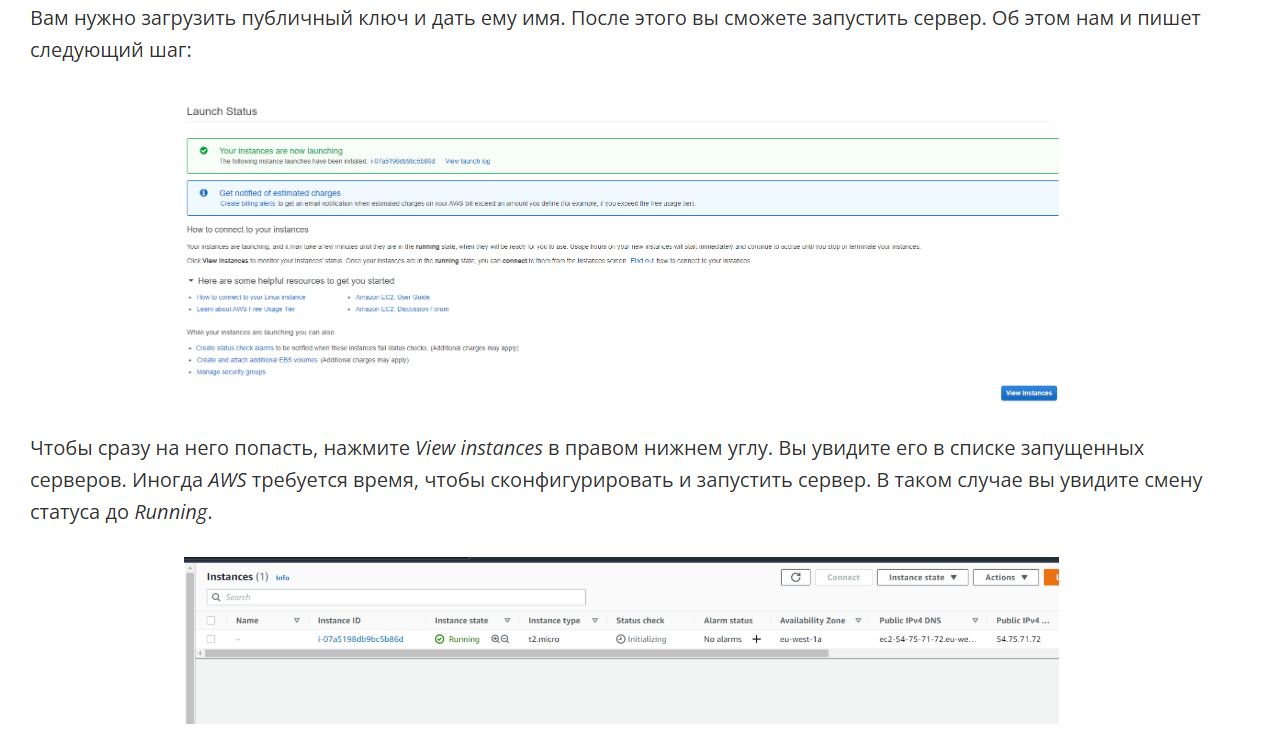

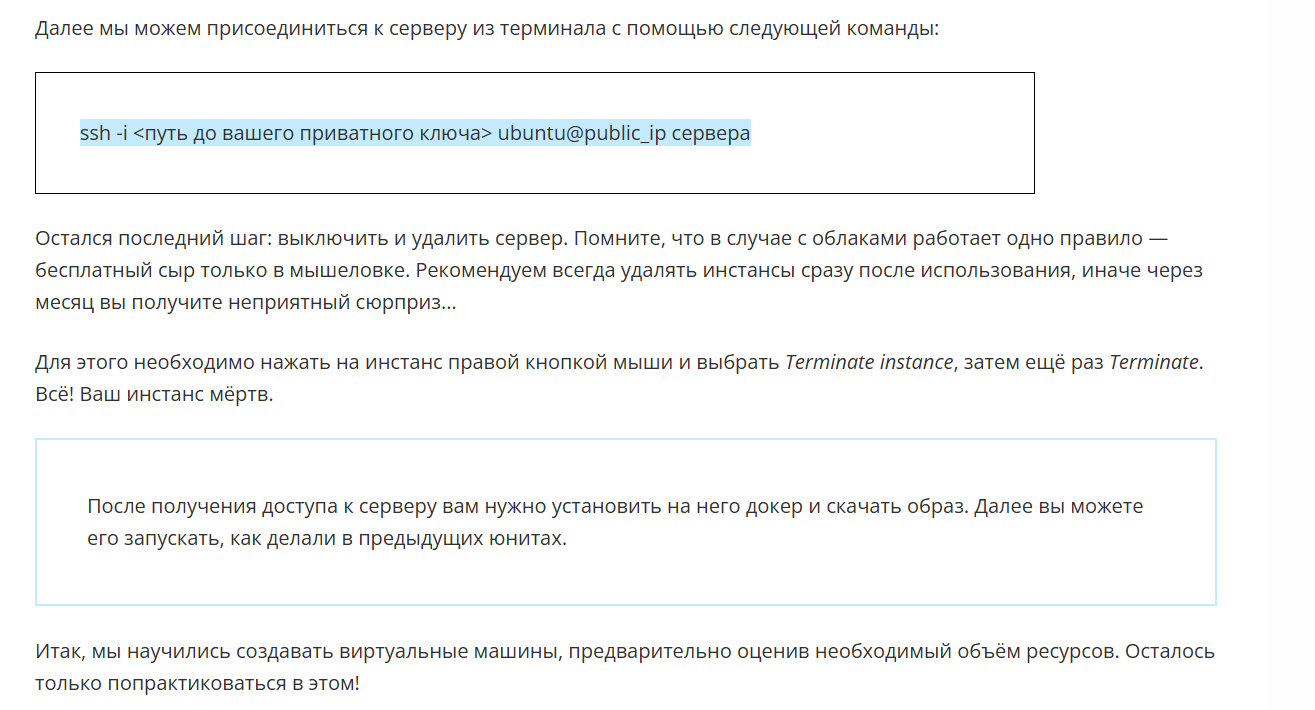

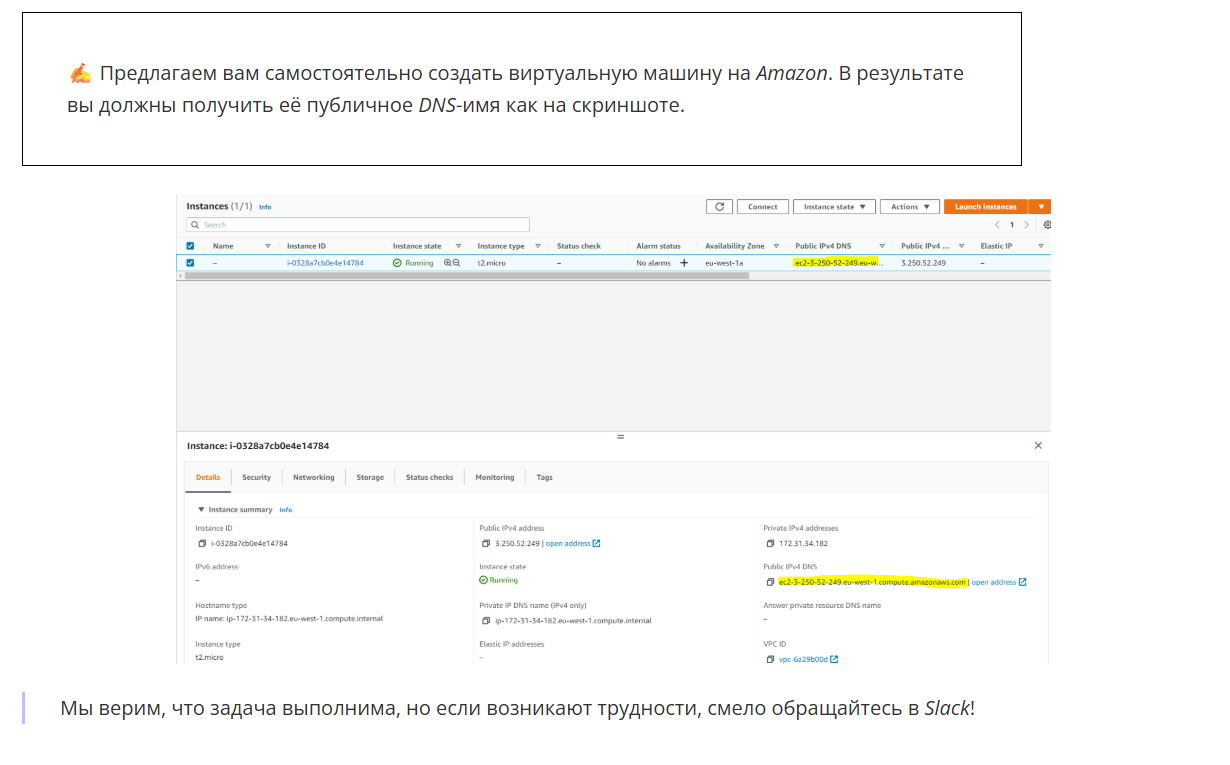

# 9. Подведём итоги

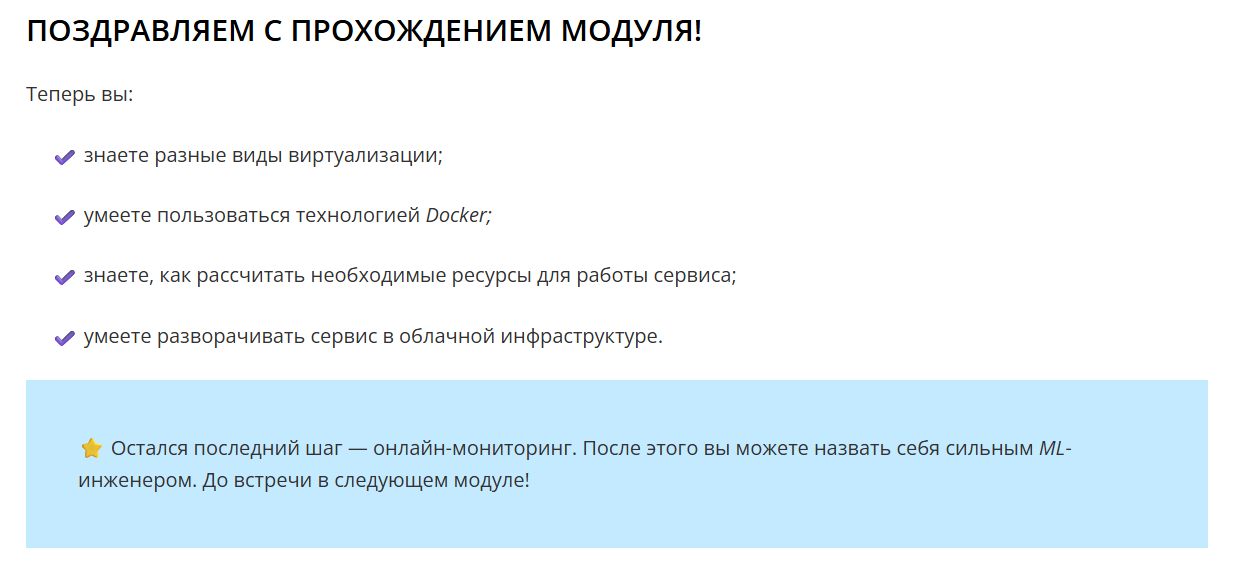